In [ ]:
!pip install ruptures
!pip install --upgrade yfinance;
!pip install --upgrade pip
!auto_adjust=False, multi_level_index=False
!pip install seaborn
!pip install codecarbon


In [ ]:
from tabulate import tabulate
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import ruptures as rpt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import math
import pandas as pd
import seaborn as sns
import random
import pickle
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, LSTM, GRU, Bidirectional, Add, LayerNormalization, MultiHeadAttention, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import time
import glob
import os

from codecarbon import EmissionsTracker
from sklearn.preprocessing import MinMaxScaler
import matplotlib
if not hasattr(matplotlib.cm, 'register_cmap'):
    def register_cmap(name, cmap):
        pass
    matplotlib.cm.register_cmap = register_cmap


In [ ]:
# -*- coding: utf-8 -*-
"""
PAPERSPACE Paper Particion datos unidimensional.ipynb

Script completo que descarga datos financieros, genera particiones temporales,
construye y evalúa diferentes modelos (incluida la red LSTM optimizada individualmente para cada activo),
y genera visualizaciones y tablas con los resultados.
"""

# %% Instalación de librerías (si es necesario)
# !pip install ruptures
# !pip install --upgrade yfinance
# !pip install --upgrade pip
# !pip install seaborn
# !pip install codecarbon

import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '123'

import tensorflow as tf
tf.config.experimental.enable_op_determinism()

print("Configured to use 16 CPU threads.")
print("XLA JIT compilation enabled.")

# %% Imports y configuración inicial
from tabulate import tabulate
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import ruptures as rpt

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import math
import pandas as pd
import seaborn as sns
import random
import pickle
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dense, LSTM, GRU, BatchNormalization, Add, LayerNormalization, MultiHeadAttention, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import time
import glob
os.environ["CODECARBON_COUNTRY"] = "ESP"

from codecarbon import EmissionsTracker
from sklearn.preprocessing import MinMaxScaler
import matplotlib
if not hasattr(matplotlib.cm, 'register_cmap'):
    def register_cmap(name, cmap):
        pass
    matplotlib.cm.register_cmap = register_cmap

optimal_hyperparams = {
    "Bitcoin": {
         "LSTM": {
             "units": [128, 64],
             "dropout": 0.15,
             "learning_rate": 0.0005,
             "epochs": 150,
             "extra_dense": True
         },
         "TRANSFORMER": {
             "d_model": 80,
             "num_heads": 4,
             "dropout": 0.1,
             "learning_rate": 0.0002,
             "epochs": 150
         }
    },
    "Ethereum": {
         "LSTM": {
             "units": [256, 128],
             "dropout": 0.05,
             "learning_rate": 0.0004,
             "epochs": 300,
             "extra_dense": True,
             "use_extra_layers": True
         },
         "Multilayer Perceptron": {
             "layers": [64, 32],
             "dropout": 0.10,
             "learning_rate": 0.0008,
             "epochs": 150
         }
    },
    "Litecoin": {
         "LSTM": {
             "units": [256, 128],
             "dropout": 0.05,
             "learning_rate": 0.0003,
             "epochs": 300,
             "extra_dense": True,
             "use_extra_layers": True
         },
         "Multilayer Perceptron": {
             "layers": [64, 32, 16],
             "dropout": 0.05,
             "learning_rate": 0.0005,
             "epochs": 150
         },
         "TRANSFORMER": {
             "d_model": 50,
             "num_heads": 2,
             "dropout": 0.05,
             "learning_rate": 0.0001,
             "epochs": 150
         }
    },
    "Bitcoin Cash": {
         "LSTM": {
             "units": [128, 64],
             "dropout": 0.15,
             "learning_rate": 0.0005,
             "epochs": 150,
             "extra_dense": True
         }
    },
    "Cardano": {
         "LSTM": {
             "units": [64, 32],
             "dropout": 0.10,
             "learning_rate": 0.0003,
             "epochs": 150,
             "extra_dense": True
         }
    },
    "Polkadot": {
         "LSTM": {
             "units": [128, 64],
             "dropout": 0.15,
             "learning_rate": 0.0005,
             "epochs": 150,
             "extra_dense": False
         }
    },
    "Solana": {
         "LSTM": {
             "units": [512, 256],
             "dropout": 0.05,
             "learning_rate": 0.0003,
             "epochs": 250,
             "extra_dense": True,
             "use_extra_layers": True
         },
         "Multilayer Perceptron": {
             "layers": [64, 32],
             "dropout": 0.10,
             "learning_rate": 0.001,
             "epochs": 150
         }
    },
    "Binance Coin": {
         "LSTM": {
             "units": [128, 64],
             "dropout": 0.10,
             "learning_rate": 0.0005,
             "epochs": 150,
             "extra_dense": True
         }
    },
    "TRON": {
         "LSTM": {
             "units": [256, 256],
             "dropout": 0.05,
             "learning_rate": 0.00035,
             "epochs": 150,
             "extra_dense": True,
             "use_extra_layers": True
         },
         "TRANSFORMER": {
             "d_model": 64,
             "num_heads": 4,
             "dropout": 0.1,
             "learning_rate": 0.0003,
             "epochs": 150
         }
    },
    "Monero": {
         "LSTM": {
             "units": [256, 128],
             "dropout": 0.10,
             "learning_rate": 0.0003,
             "epochs": 150,
             "extra_dense": True
         },
         "Multilayer Perceptron": {
             "layers": [64, 32],
             "dropout": 0.05,
             "learning_rate": 0.0005,
             "epochs": 150
         },
         "GRU": {
             "units": [256, 128],
             "dropout": 0.05,
             "learning_rate": 0.0003,
             "epochs": 150
         }
    },
    "Ripple": {
         "LSTM": {
             "units": [64, 32],
             "dropout": 0.05,
             "learning_rate": 0.0004,
             "epochs": 150,
             "extra_dense": True
         }
    },
    "Stellar": {
         "LSTM": {
             "units": [64, 32],
             "dropout": 0.05,
             "learning_rate": 0.0004,
             "epochs": 150,
             "extra_dense": True
         }
    }
}

# %% Funciones de partición y creación de instancias
def crear_instancias(serie, tam_ventana):
    X, y, idx = [], [], []
    for i in range(len(serie) - tam_ventana):
        X.append(serie[i:i+tam_ventana])
        y.append(serie[i+tam_ventana])
        idx.append(i+tam_ventana)
    return np.array(X), np.array(y), np.array(idx)

def calcular_tamanos(nb):
    tam_train = round(TRAIN_PERCENT * nb)
    tam_val = round(0.10 * nb)
    tam_test = nb - tam_train - tam_val
    return tam_train, tam_val, tam_test

def obtener_particion(serie, tam_ventana, metodo):
    print(f"[INFO] {METODOS_MAP[metodo]}: Generating partition for series of length {len(serie)}")
    X, y, idx = crear_instancias(serie, tam_ventana)
    nb = len(X)
    tam_train, tam_val, tam_test = calcular_tamanos(nb)
    if metodo == "no_aleatoria":
        X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(X, y, idx, test_size=(tam_test+tam_val), shuffle=False)
        X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(X_temp, y_temp, idx_temp, test_size=(tam_test/(tam_test+tam_val)), shuffle=False)
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "secuencial_con_mezcla":
        X_train = X[:tam_train]
        y_train = y[:tam_train]
        idx_train = idx[:tam_train]
        X_val = X[tam_train:tam_train+tam_val]
        y_val = y[tam_train:tam_train+tam_val]
        idx_val = idx[tam_train:tam_train+tam_val]
        X_test = X[tam_train+tam_val:]
        y_test = y[tam_train+tam_val:]
        idx_test = idx[tam_train+tam_val:]
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "pre-paper_no_shuffle":
        X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, idx, test_size=tam_test, shuffle=False)
        X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(X_train, y_train, idx_train, test_size=tam_test, shuffle=False)
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "ventana_movil2":
        train_end = len(X) - (tam_val + tam_test)
        X_train = X[:train_end]
        y_train = y[:train_end]
        idx_train = idx[:train_end]
        X_val = X[train_end:train_end+tam_val]
        y_val = y[train_end:train_end+tam_val]
        idx_val = idx[train_end:train_end+tam_val]
        X_test = X[train_end+tam_val:]
        y_test = y[train_end+tam_val:]
        idx_test = idx[train_end+tam_val:]
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "con_solape":
        n_blocks = len(serie) - tam_ventana + 1
        X_blocks = np.array([serie[i:i+tam_ventana] for i in range(n_blocks)], dtype=np.float32)
        y_blocks = np.array([serie[i+tam_ventana-1] for i in range(n_blocks)], dtype=np.float32)
        idx_blocks = np.array([i+tam_ventana-1 for i in range(n_blocks)])
        nb_blocks = len(X_blocks)
        train_size = int(TRAIN_PERCENT * nb_blocks)
        test_size = int(TEST_PERCENT * nb_blocks)
        val_size = nb_blocks - train_size - test_size
        X_train = X_blocks[:train_size]
        y_train = y_blocks[:train_size]
        idx_train = idx_blocks[:train_size]
        X_val = X_blocks[train_size:train_size+val_size]
        y_val = y_blocks[train_size:train_size+val_size]
        idx_val = idx_blocks[train_size:train_size+val_size]
        X_test = X_blocks[train_size+val_size:]
        y_test = y_blocks[train_size+val_size:]
        idx_test = idx_blocks[train_size+val_size:]
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "time_series_split":
        tscv = TimeSeriesSplit(n_splits=5)
        for train_idx, test_idx in tscv.split(X):
            pass  # Usamos la última partición
        X_train = X[train_idx]
        y_train = y[train_idx]
        idx_train = idx[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        idx_test = idx[test_idx]
        L = len(test_idx)
        val_size = round(L/3)
        idx_val = test_idx[:val_size]
        idx_test = test_idx[val_size:]
        X_val = X[idx_val]
        y_val = y[idx_val]
        X_test = X[idx_test]
        y_test = y[idx_test]
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "timeseries_generator":
        train_series = serie[:tam_train + WINDOW_SIZE]
        val_series = serie[tam_train:tam_train + tam_val + WINDOW_SIZE]
        test_series = serie[tam_train + tam_val:tam_train + tam_val + tam_test + WINDOW_SIZE]
        gen_train = TimeseriesGenerator(train_series, train_series, length=tam_ventana, batch_size=len(train_series))
        gen_val = TimeseriesGenerator(val_series, val_series, length=tam_ventana, batch_size=len(val_series))
        gen_test = TimeseriesGenerator(test_series, test_series, length=tam_ventana, batch_size=len(test_series))
        X_train, y_train = gen_train[0][0], gen_train[0][1]
        X_val, y_val = gen_val[0][0], gen_val[0][1]
        X_test, y_test = gen_test[0][0], gen_test[0][1]
        idx_train = np.arange(tam_ventana, tam_train + WINDOW_SIZE)
        idx_val = np.arange(tam_train + WINDOW_SIZE, tam_train + tam_val + WINDOW_SIZE)
        idx_test = np.arange(tam_train + tam_val + WINDOW_SIZE, tam_train + tam_val + tam_test + WINDOW_SIZE)
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    elif metodo == "purged_kfold":
        def purged_kfold_split(X, y, idx, n_splits=5, purge_size=5):
            n = len(X)
            fold_size = n // n_splits
            folds = []
            for i in range(n_splits):
                inicio = i * fold_size
                fin = n if i == n_splits - 1 else (i + 1) * fold_size
                folds.append((inicio, fin))
            splits = []
            for i in range(n_splits):
                test_indices = list(range(folds[i][0], folds[i][1]))
                train_indices = []
                for j in range(n_splits):
                    if j == i:
                        continue
                    if j == i - 1:
                        train_indices.extend(list(range(folds[j][0], max(folds[j][1] - purge_size, folds[j][0]))))
                    elif j == i + 1:
                        train_indices.extend(list(range(folds[j][0] + purge_size, folds[j][1])))
                    else:
                        train_indices.extend(list(range(folds[j][0], folds[j][1])))
                splits.append((np.array(train_indices), np.array(test_indices)))
            return splits
        splits = purged_kfold_split(*crear_instancias(serie, tam_ventana), n_splits=5, purge_size=5)
        train_idx, test_idx = splits[-1]
        X_all, y_all, idx_all = crear_instancias(serie, tam_ventana)
        return (X_all[train_idx], y_all[train_idx],
                X_all[test_idx], y_all[test_idx],
                X_all[test_idx], y_all[test_idx],
                idx_all[train_idx], idx_all[train_idx], idx_all[test_idx])
    elif metodo == "change_point_partitioning":
        X, y, idx = crear_instancias(serie, tam_ventana)
        nb = len(X)
        tam_train, tam_val, tam_test = calcular_tamanos(nb)
        desired_cp1 = WINDOW_SIZE + tam_train
        desired_cp2 = WINDOW_SIZE + tam_train + tam_val
        algo = rpt.Pelt(model="rbf").fit(serie)
        detected_cps = algo.predict(pen=10)
        if detected_cps:
            cp1 = min(detected_cps, key=lambda cp: abs(cp - desired_cp1))
            candidate_cps = [cp for cp in detected_cps if cp > cp1]
            cp2 = min(candidate_cps, key=lambda cp: abs(cp - desired_cp2)) if candidate_cps else desired_cp2
        else:
            cp1, cp2 = desired_cp1, desired_cp2
        indices_all = np.arange(WINDOW_SIZE, len(serie))
        test_mask = indices_all >= cp2
        if np.sum(test_mask) < tam_test:
            cp2 = indices_all[-tam_test]
        train_mask = indices_all < cp1
        val_mask = (indices_all >= cp1) & (indices_all < cp2)
        test_mask = indices_all >= cp2
        X_train = X[train_mask]
        y_train = y[train_mask]
        idx_train = idx[train_mask]
        X_val = X[val_mask]
        y_val = y[val_mask]
        idx_val = idx[val_mask]
        X_test = X[test_mask]
        y_test = y[test_mask]
        idx_test = idx[test_mask]
        print(f"[INFO] {METODOS_MAP['change_point_partitioning']} generated. cp1: {cp1}, cp2: {cp2}")
        return X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test
    else:
        raise ValueError("Partitioning method not implemented for this version.")

def chronological_holdout(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "no_aleatoria")

def sequential_contiguous_split(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "secuencial_con_mezcla")

def sequential_split_no_shuffle(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "pre-paper_no_shuffle")

def expanding_window_validation(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "ventana_movil2")

def overlapping_window_partitioning(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "con_solape")

def timeseries_split_fixed_cv(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "time_series_split")

def generator_based_temporal_partitioning(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "timeseries_generator")

def purged_kfold_cv(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "purged_kfold")

def changepoint_based_partitioning(serie, tam_ventana):
    return obtener_particion(serie, tam_ventana, "change_point_partitioning")

def particiones_evolutivas(func_partition, n_min, n_max, steps):
    n_values = np.linspace(n_min, n_max, steps, dtype=int)
    particiones = []
    for n_actual in n_values:
        serie_actual = np.arange(n_actual)
        partition = func_partition(serie_actual, WINDOW_SIZE)
        idx_train, idx_val, idx_test = partition[-3], partition[-2], partition[-1]
        particiones.append((n_actual, idx_train, idx_val, idx_test))
    return n_values, particiones

# %% BLOQUE DE EVALUACIÓN DE MODELOS
# Se optimizan los parámetros LSTM para los activos indicados; el resto usará la configuración por defecto.
# (Se ha añadido la optimización para el modelo TRANSFORMER en los activos TRON, Bitcoin y Litecoin)
modelos = {
    "Multilayer Perceptron": None,  # Se construye a continuación
    "LSTM": None,
    "GRU": None,
    "TRANSFORMER": None,
    "BiLSTM": None
}

def construir_modelo_perceptron(tam_ventana, asset_name=None):
    if asset_name is not None and asset_name in optimal_hyperparams and "Multilayer Perceptron" in optimal_hyperparams[asset_name]:
        params = optimal_hyperparams[asset_name]["Multilayer Perceptron"]
        layers = params["layers"]
        dropout = params["dropout"]
        lr = params["learning_rate"]
        print(f"[INFO] Building optimized MLP model for {asset_name} with parameters: {params}")
        model = Sequential([Input(shape=(tam_ventana, 1)), Flatten()])
        for units in layers:
            model.add(Dense(units, activation='relu'))
            model.add(Dropout(dropout))
        model.add(Dense(1, activation='linear'))
    else:
        print("[INFO] Building default MLP model")
        model = Sequential([
            Input(shape=(tam_ventana, 1)),
            Flatten(),
            Dense(32, activation='relu'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='linear')
        ])
        lr = LEARNING_RATE
    model.compile(optimizer=Adam(learning_rate=lr), loss='mae')
    return model

def construir_modelo_lstm(tam_ventana, asset_name):
    if asset_name is not None and asset_name in optimal_hyperparams and "LSTM" in optimal_hyperparams[asset_name]:
        params = optimal_hyperparams[asset_name]["LSTM"]
        print(f"[INFO] Building optimized LSTM model for {asset_name} with parameters: {params}")
        model = Sequential()
        model.add(Input(shape=(tam_ventana, 1)))
        model.add(LSTM(params["units"][0], return_sequences=True, dropout=params["dropout"], recurrent_dropout=params["dropout"]))
        model.add(LSTM(params["units"][1], return_sequences=False, dropout=params["dropout"], recurrent_dropout=params["dropout"]))
        if params.get("use_extra_layers", False):
            model.add(BatchNormalization())
            model.add(Dense(64, activation='relu'))
            model.add(Dropout(params["dropout"]))
            model.add(Dense(32, activation='relu'))
            model.add(Dropout(params["dropout"]))
            model.add(Dense(1, activation='linear'))
        else:
            if params.get("extra_dense", False):
                model.add(Dense(32, activation='relu'))
                model.add(Dropout(params["dropout"]))
            model.add(Dense(16, activation='relu'))
            model.add(Dense(1, activation='linear'))
        lr = params["learning_rate"]
    else:
        params = {"units": [128, 64], "dropout": 0.3, "learning_rate": 0.001}
        print(f"[INFO] Building default LSTM model for {asset_name} with parameters: {params}")
        model = Sequential([
            Input(shape=(tam_ventana, 1)),
            LSTM(params["units"][0], return_sequences=True, dropout=params["dropout"], recurrent_dropout=params["dropout"]),
            LSTM(params["units"][1], dropout=params["dropout"], recurrent_dropout=params["dropout"]),
            Dense(16, activation='relu'),
            Dense(1, activation='linear')
        ])
        lr = params["learning_rate"]
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

def construir_modelo_gru(tam_ventana, asset_name):
    if asset_name is not None and asset_name in optimal_hyperparams and "GRU" in optimal_hyperparams[asset_name]:
        params = optimal_hyperparams[asset_name]["GRU"]
        print(f"[INFO] Building optimized GRU model for {asset_name} with parameters: {params}")
        model = Sequential([Input(shape=(tam_ventana, 1))])
        model.add(GRU(params["units"][0], return_sequences=True, dropout=params["dropout"], recurrent_dropout=params["dropout"]))
        model.add(GRU(params["units"][1], return_sequences=False, dropout=params["dropout"], recurrent_dropout=params["dropout"]))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(1, activation='linear'))
        lr = params["learning_rate"]
    else:
        params = {"units": [128, 64], "dropout": 0.1, "learning_rate": 0.001}
        print(f"[INFO] Building default GRU model for {asset_name} with parameters: {params}")
        model = Sequential([
            Input(shape=(tam_ventana, 1)),
            GRU(params["units"][0], return_sequences=True, dropout=params["dropout"], recurrent_dropout=params["dropout"]),
            GRU(params["units"][1], dropout=params["dropout"], recurrent_dropout=params["dropout"]),
            Dense(16, activation='relu'),
            Dense(1, activation='linear')
        ])
        lr = params["learning_rate"]
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

def construir_modelo_transformer(tam_ventana, asset_name=None):
    if asset_name is not None and asset_name in optimal_hyperparams and "TRANSFORMER" in optimal_hyperparams[asset_name]:
        params = optimal_hyperparams[asset_name]["TRANSFORMER"]
        print(f"[INFO] Building optimized TRANSFORMER model for {asset_name} with parameters: {params}")
        d_model = params["d_model"]
        num_heads = params["num_heads"]
        dropout_rate = params["dropout"]
        lr = params["learning_rate"]
    else:
        d_model = 50
        num_heads = 2
        dropout_rate = 0.2
        lr = LEARNING_RATE
        print(f"[INFO] Building default TRANSFORMER model for {asset_name}")
    inputs = Input(shape=(tam_ventana, 1))
    x = Dense(d_model, activation='relu')(inputs)
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    x = Add()([x, attn_output])
    x = LayerNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Flatten()(x)
    x = Dense(25, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=lr), loss='mae')
    return model

def construir_modelo_bidi(tam_ventana, asset_name=None):
    if asset_name is not None and asset_name in optimal_hyperparams and "BiLSTM" in optimal_hyperparams[asset_name]:
        params = optimal_hyperparams[asset_name]["BiLSTM"]
        print(f"[INFO] Building optimized BiLSTM model for {asset_name} with parameters: {params}")
        model = Sequential([
            Input(shape=(tam_ventana, 1)),
            tf.keras.layers.Bidirectional(LSTM(params["units"][0], return_sequences=True, dropout=params["dropout"], recurrent_dropout=params["dropout"])),
            tf.keras.layers.Bidirectional(LSTM(params["units"][1], dropout=params["dropout"], recurrent_dropout=params["dropout"])),
            Dense(32, activation='relu'),
            Dense(1, activation='linear')
        ])
        lr = params["learning_rate"]
    else:
        print(f"[INFO] Building default BiLSTM model for {asset_name}")
        model = Sequential([
            Input(shape=(tam_ventana, 1)),
            tf.keras.layers.Bidirectional(LSTM(50)),
            Dropout(0.2),
            Dense(1, activation='linear')
        ])
        lr = 0.001
    model.compile(optimizer=Adam(learning_rate=lr), loss='mae')
    return model

modelos = {
    "Multilayer Perceptron": construir_modelo_perceptron,
    "LSTM": construir_modelo_lstm,
    "GRU": construir_modelo_gru,
    "TRANSFORMER": construir_modelo_transformer,
    "BiLSTM": construir_modelo_bidi
}

def entrenar_evaluar_modelo(funcion_modelo, tam_ventana, X_train, y_train, X_val, y_val, X_test, y_test, epochs):
    print(f"[INFO] Training model {funcion_modelo.__name__} for {epochs} epochs")
    model = funcion_modelo(tam_ventana)
    tracker = EmissionsTracker(project_name="TimeSeries Models Training", log_level="info")
    tracker.start()
    inicio = time.time()
    model.fit(X_train.reshape(-1, tam_ventana, 1), y_train,
              validation_data=(X_val.reshape(-1, tam_ventana, 1), y_val),
              epochs=epochs, verbose=0)
    tiempo_ejecucion = time.time() - inicio
    emisiones = tracker.stop()
    print(f"[INFO] Training completed in {tiempo_ejecucion:.2f} seconds")
    print(f"[INFO] Estimated emissions: {emisiones:.4f} kgCO2eq")
    preds = model.predict(X_test.reshape(-1, tam_ventana, 1), verbose=0).flatten()
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2 = r2_score(y_test, preds) if len(y_test) >= 2 else np.nan
    return mse, rmse, mae, mape, r2, tiempo_ejecucion, emisiones, preds, y_test

def evaluate_model_asset(model_name, funcion_modelo, asset_name, serie, metodo, epochs_default):
    print(f"[INFO] Evaluating model '{model_name}' on asset '{asset_name}' using {METODOS_MAP[metodo]}")
    try:
        particion = obtener_particion(serie, WINDOW_SIZE, metodo)
    except Exception as e:
        print(f"[ERROR] Error on asset {asset_name}, model {model_name}, method {metodo}: {e}")
        return None
    X_train, y_train, X_val, y_val, X_test, y_test, idx_train, idx_val, idx_test = particion
    if X_test.shape[0] == 0:
        print(f"[WARNING] The partition for {asset_name} using {METODOS_MAP[metodo]} is empty. Skipping.")
        return None
    dates = dates_dict[asset_name]
    dates_arr = dates.to_numpy()
    test_dates = dates_arr[idx_test]
    train_start = np.datetime_as_string(dates_arr[idx_train[0]], unit='D')
    train_end = np.datetime_as_string(dates_arr[idx_train[-1]], unit='D')
    valid_start = np.datetime_as_string(dates_arr[idx_val[0]], unit='D')
    valid_end = np.datetime_as_string(dates_arr[idx_val[-1]], unit='D')
    test_range_str = f"{np.datetime_as_string(test_dates[0], unit='D')} - {np.datetime_as_string(test_dates[-1], unit='D')}"
    total_samples = len(X_train) + len(X_val) + len(X_test)
    n_original = len(serie)
    result = {
        "model": model_name,
        "asset": asset_name,
        "method": metodo,
        "mse": None,
        "rmse": None,
        "mae": None,
        "mape": None,
        "r2": None,
        "time": None,
        "emissions": None,
        "preds_list": [],
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test": len(X_test),
        "train_range": f"{train_start} - {train_end}",
        "valid_range": f"{valid_start} - {valid_end}",
        "test_range": test_range_str,
        "total_samples": total_samples,
        "n_original": n_original,
        "idx_test": idx_test,
        "test_dates": test_dates
    }
    if asset_name in optimal_hyperparams and model_name in optimal_hyperparams[asset_name]:
         epochs = optimal_hyperparams[asset_name][model_name]["epochs"]
    else:
         epochs = epochs_default
    if model_name in ["LSTM", "GRU", "Multilayer Perceptron", "BiLSTM"]:
        modelo_func = lambda tam: funcion_modelo(tam, asset_name)
    else:
        modelo_func = funcion_modelo
    mse, rmse, mae, mape, r2, tiempo, emisiones, preds, y_test = entrenar_evaluar_modelo(
        modelo_func, WINDOW_SIZE, X_train, y_train, X_val, y_val, X_test, y_test, epochs
    )
    scaler = scalers[asset_name]
    preds_original = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    result["mse"] = mse
    result["rmse"] = rmse
    result["mae"] = mae
    result["mape"] = mape
    result["r2"] = r2
    result["time"] = tiempo
    result["emissions"] = emisiones
    result["preds_list"] = [(preds_original, y_test_original)]
    print(f"[INFO] Evaluation completed for model '{model_name}', asset '{asset_name}' using {METODOS_MAP[metodo]}")
    return result


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

[INFO] Downloading data for EURUSD (ticker: EURUSD=X)...
[INFO] Download completed for EURUSD. Records: 2605
[INFO] Downloading data for ATT (ticker: T)...
[INFO] Download completed for ATT. Records: 2767
[INFO] Downloading data for SLB (ticker: SLB)...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[INFO] Download completed for SLB. Records: 3773
[INFO] Downloading data for BABA (ticker: BABA)...
[INFO] Download completed for BABA. Records: 2587
[INFO] Downloading data for GOLD (ticker: GC=F)...
[INFO] Download completed for GOLD. Records: 2010
Available series options: all, EURUSD, ATT, SLB, BABA, GOLD
Enter the series to analyze (options: all, EURUSD, ATT, SLB, BABA, GOLD): ATT
Available algorithms: all, Multilayer Perceptron, LSTM, GRU, TRANSFORMER, BiLSTM
Enter the algorithms to analyze (options: all, Multilayer Perceptron, LSTM, GRU, TRANSFORMER, BiLSTM): GRU
[INFO] Selected series: ['ATT']
[INFO] Selected algorithms: ['GRU']

[INFO] Evolutionary visualization of partitions (stepped levels) for each method:

[INFO] Chronological Hold-Out
[INFO] Chronological Hold-Out: Generating partition for series of length 80
[INFO] Chronological Hold-Out: Generating partition for series of length 85
[INFO] Chronological Hold-Out: Generating partition for series of length 90
[INFO] Chrono

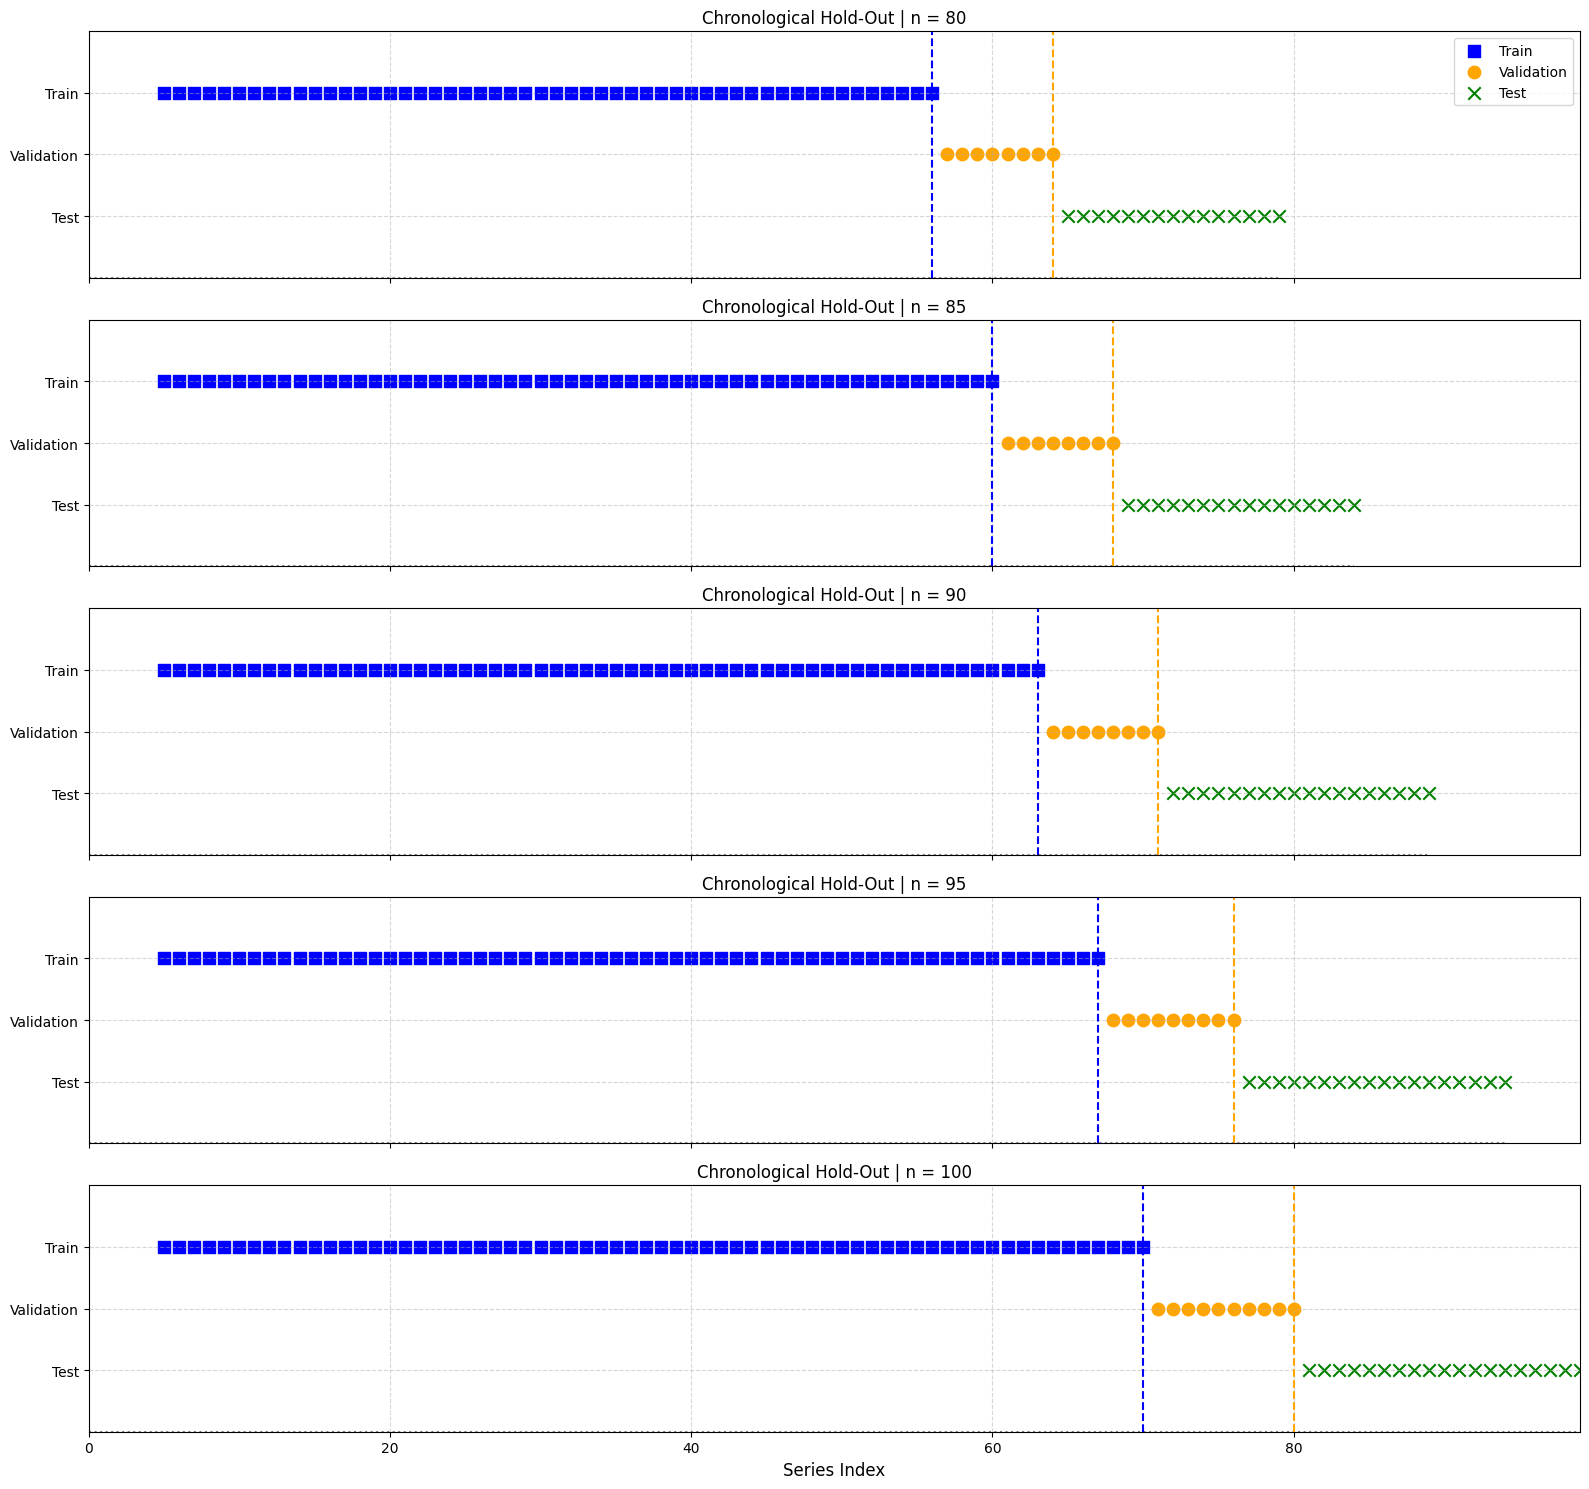


[INFO] Sequential (Contiguous) Split
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 80
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 85
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 90
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 95
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


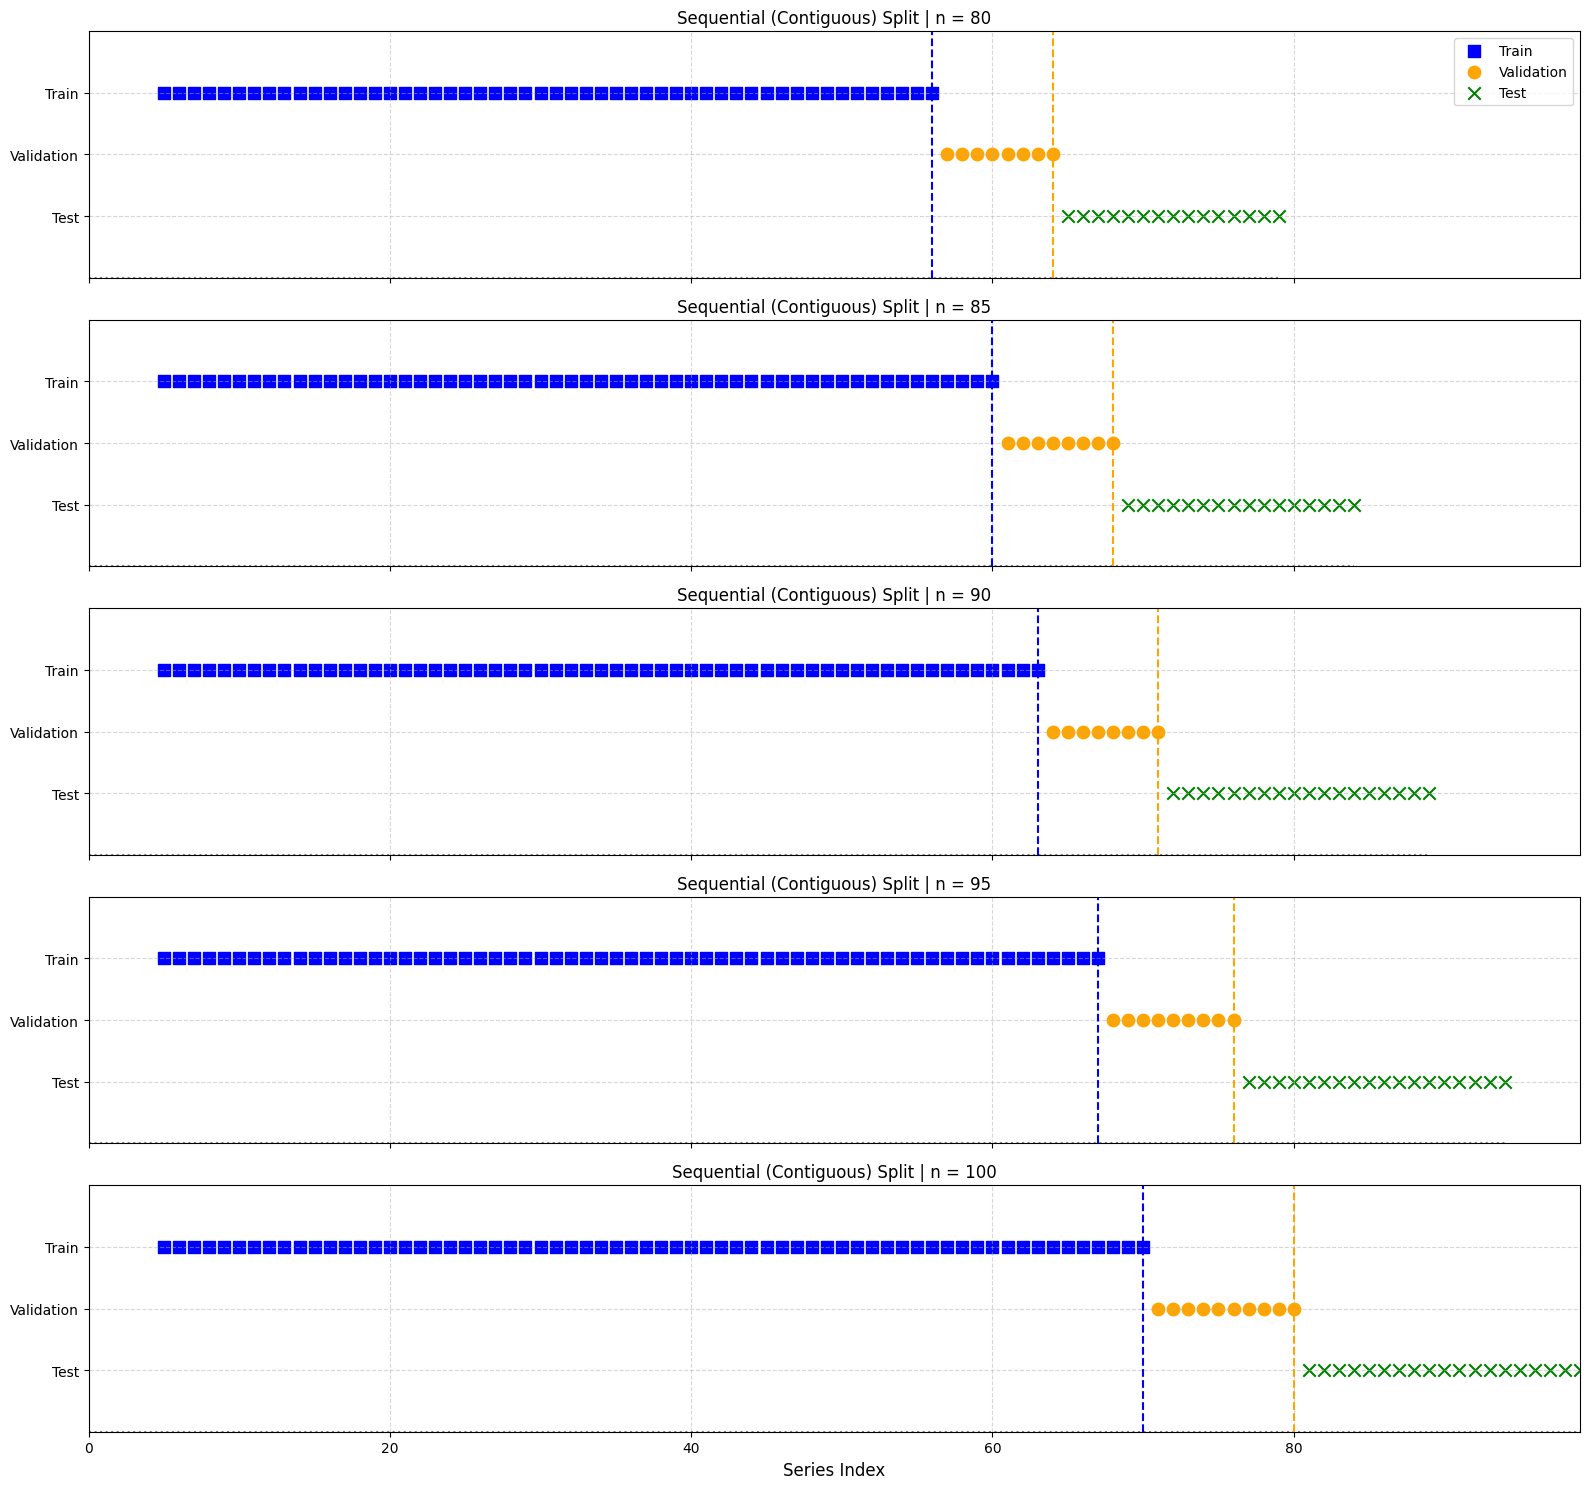


[INFO] Sequential Split (Without Shuffle)
[INFO] Sequential Split (Without Shuffle): Generating partition for series of length 80
[INFO] Sequential Split (Without Shuffle): Generating partition for series of length 85
[INFO] Sequential Split (Without Shuffle): Generating partition for series of length 90
[INFO] Sequential Split (Without Shuffle): Generating partition for series of length 95
[INFO] Sequential Split (Without Shuffle): Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


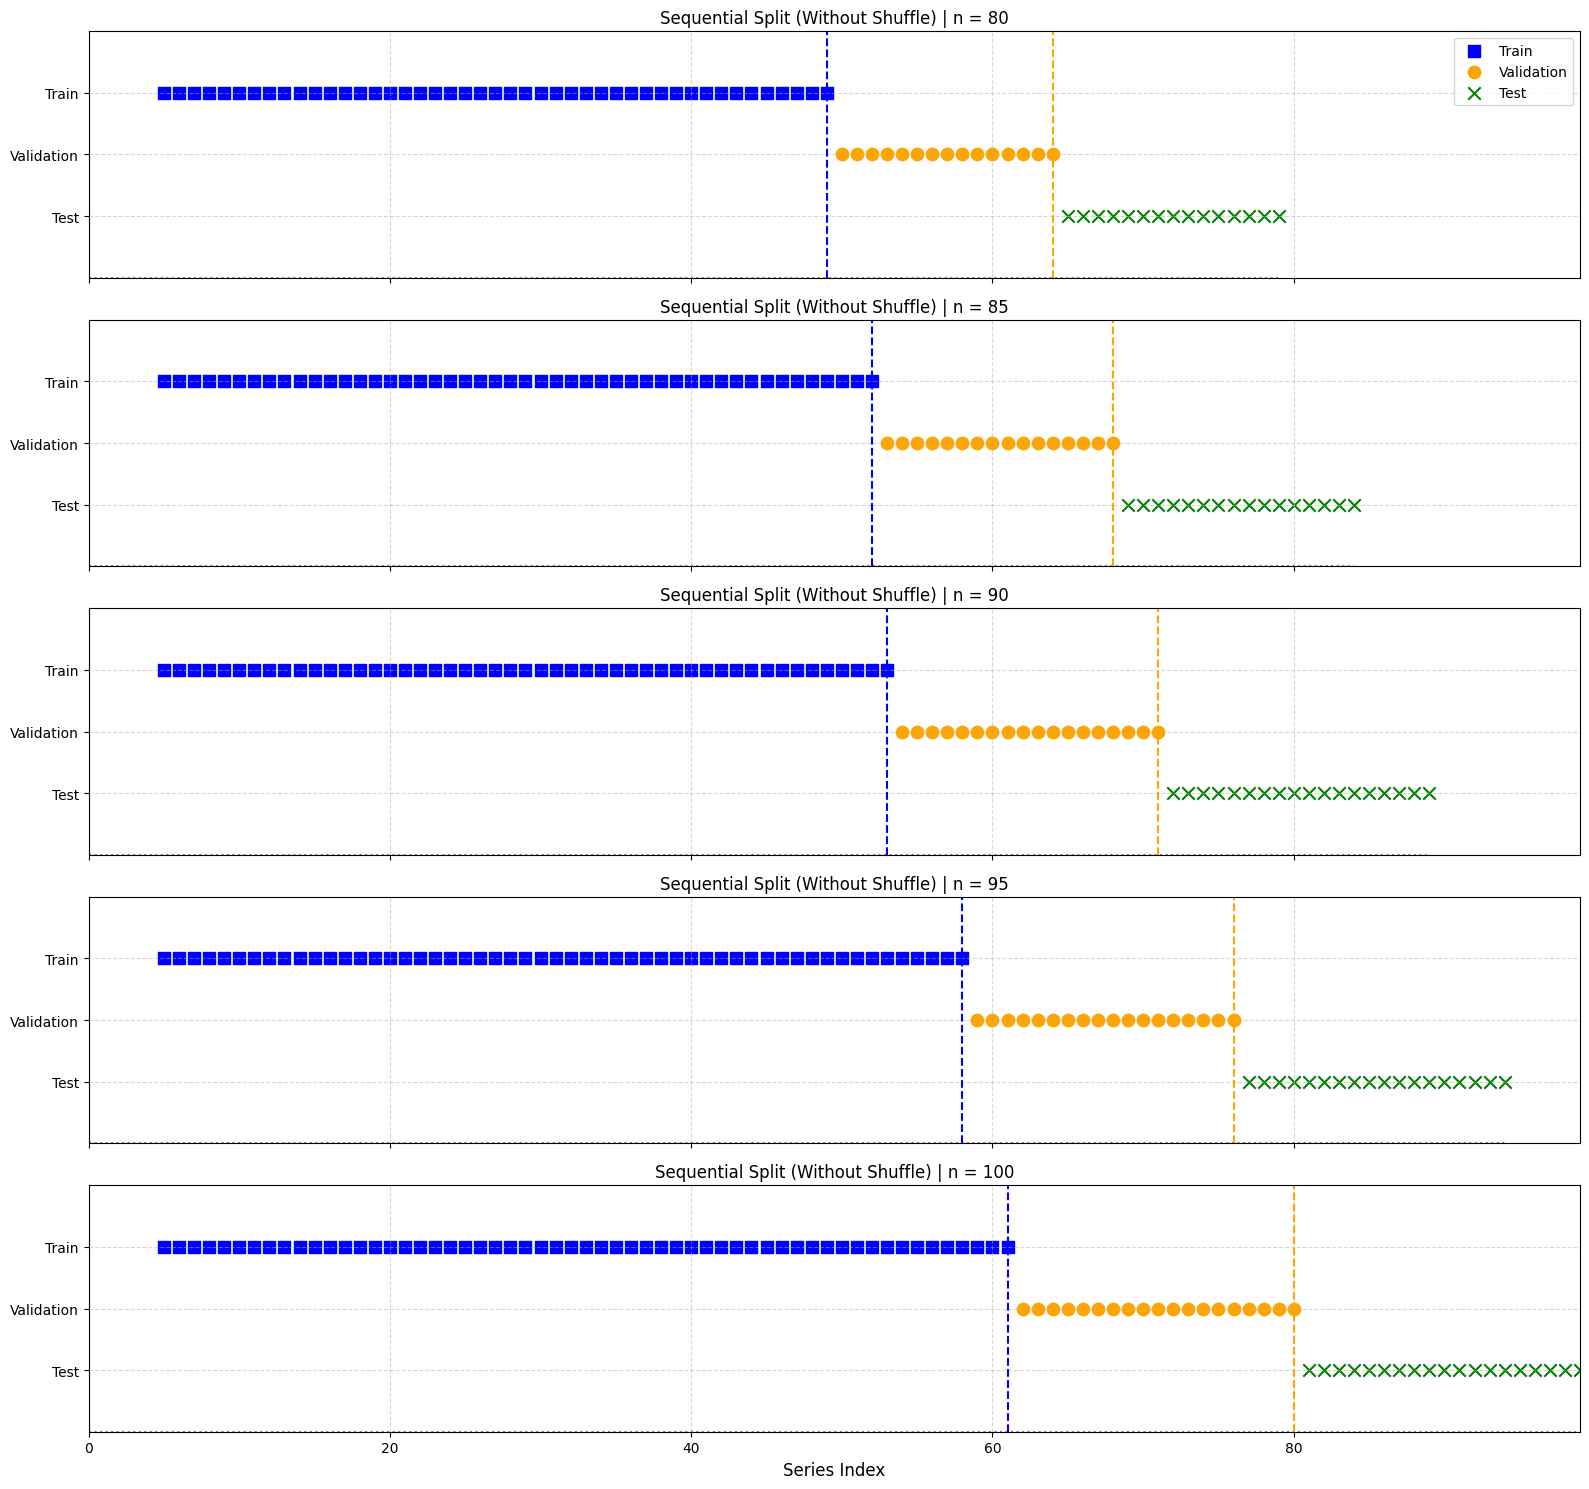


[INFO] Expanding Window Validation
[INFO] Expanding Window Validation: Generating partition for series of length 80
[INFO] Expanding Window Validation: Generating partition for series of length 85
[INFO] Expanding Window Validation: Generating partition for series of length 90
[INFO] Expanding Window Validation: Generating partition for series of length 95
[INFO] Expanding Window Validation: Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


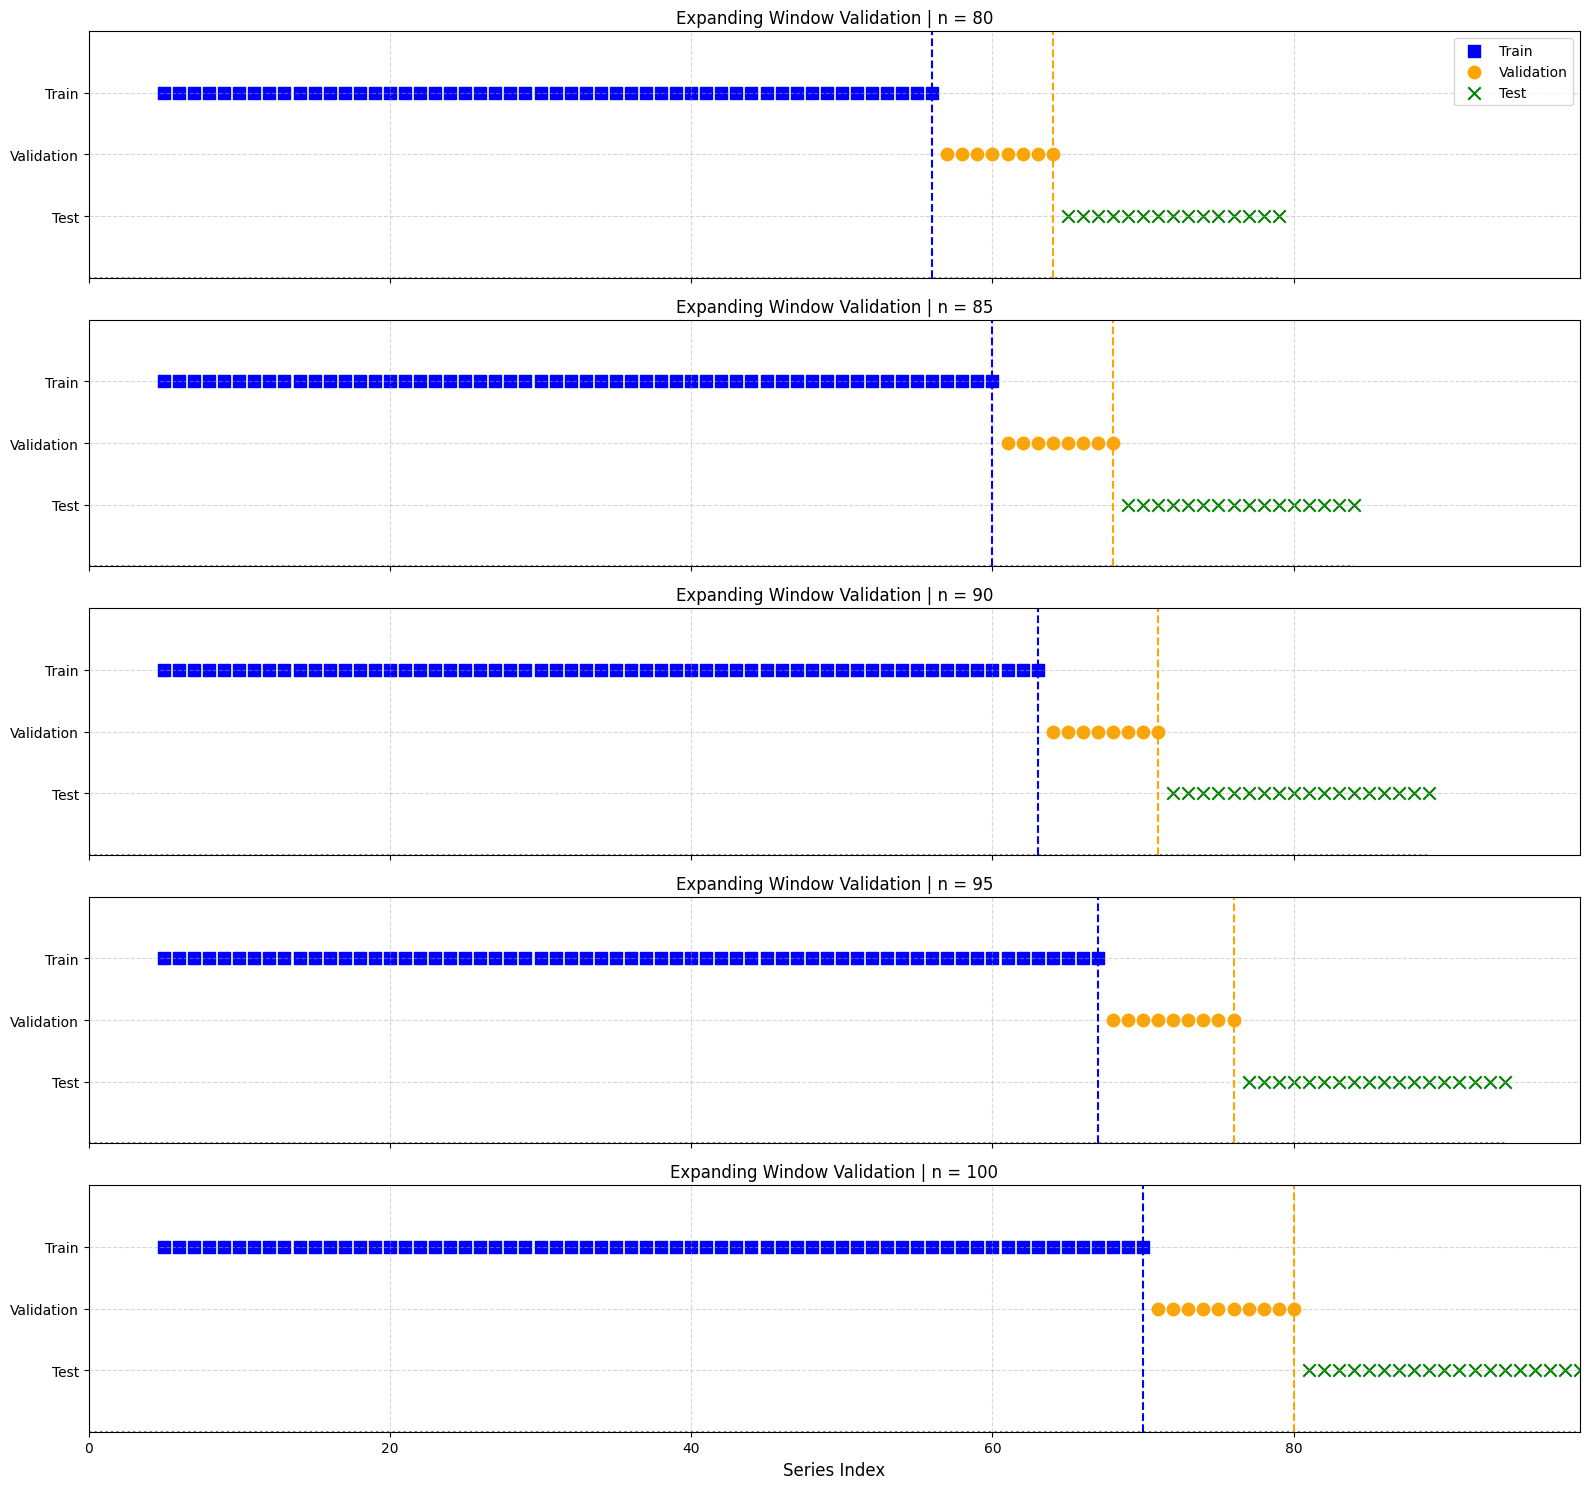


[INFO] Overlapping (Rolling) Window Partitioning
[INFO] Overlapping (Rolling) Window Partitioning: Generating partition for series of length 80
[INFO] Overlapping (Rolling) Window Partitioning: Generating partition for series of length 85
[INFO] Overlapping (Rolling) Window Partitioning: Generating partition for series of length 90
[INFO] Overlapping (Rolling) Window Partitioning: Generating partition for series of length 95
[INFO] Overlapping (Rolling) Window Partitioning: Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


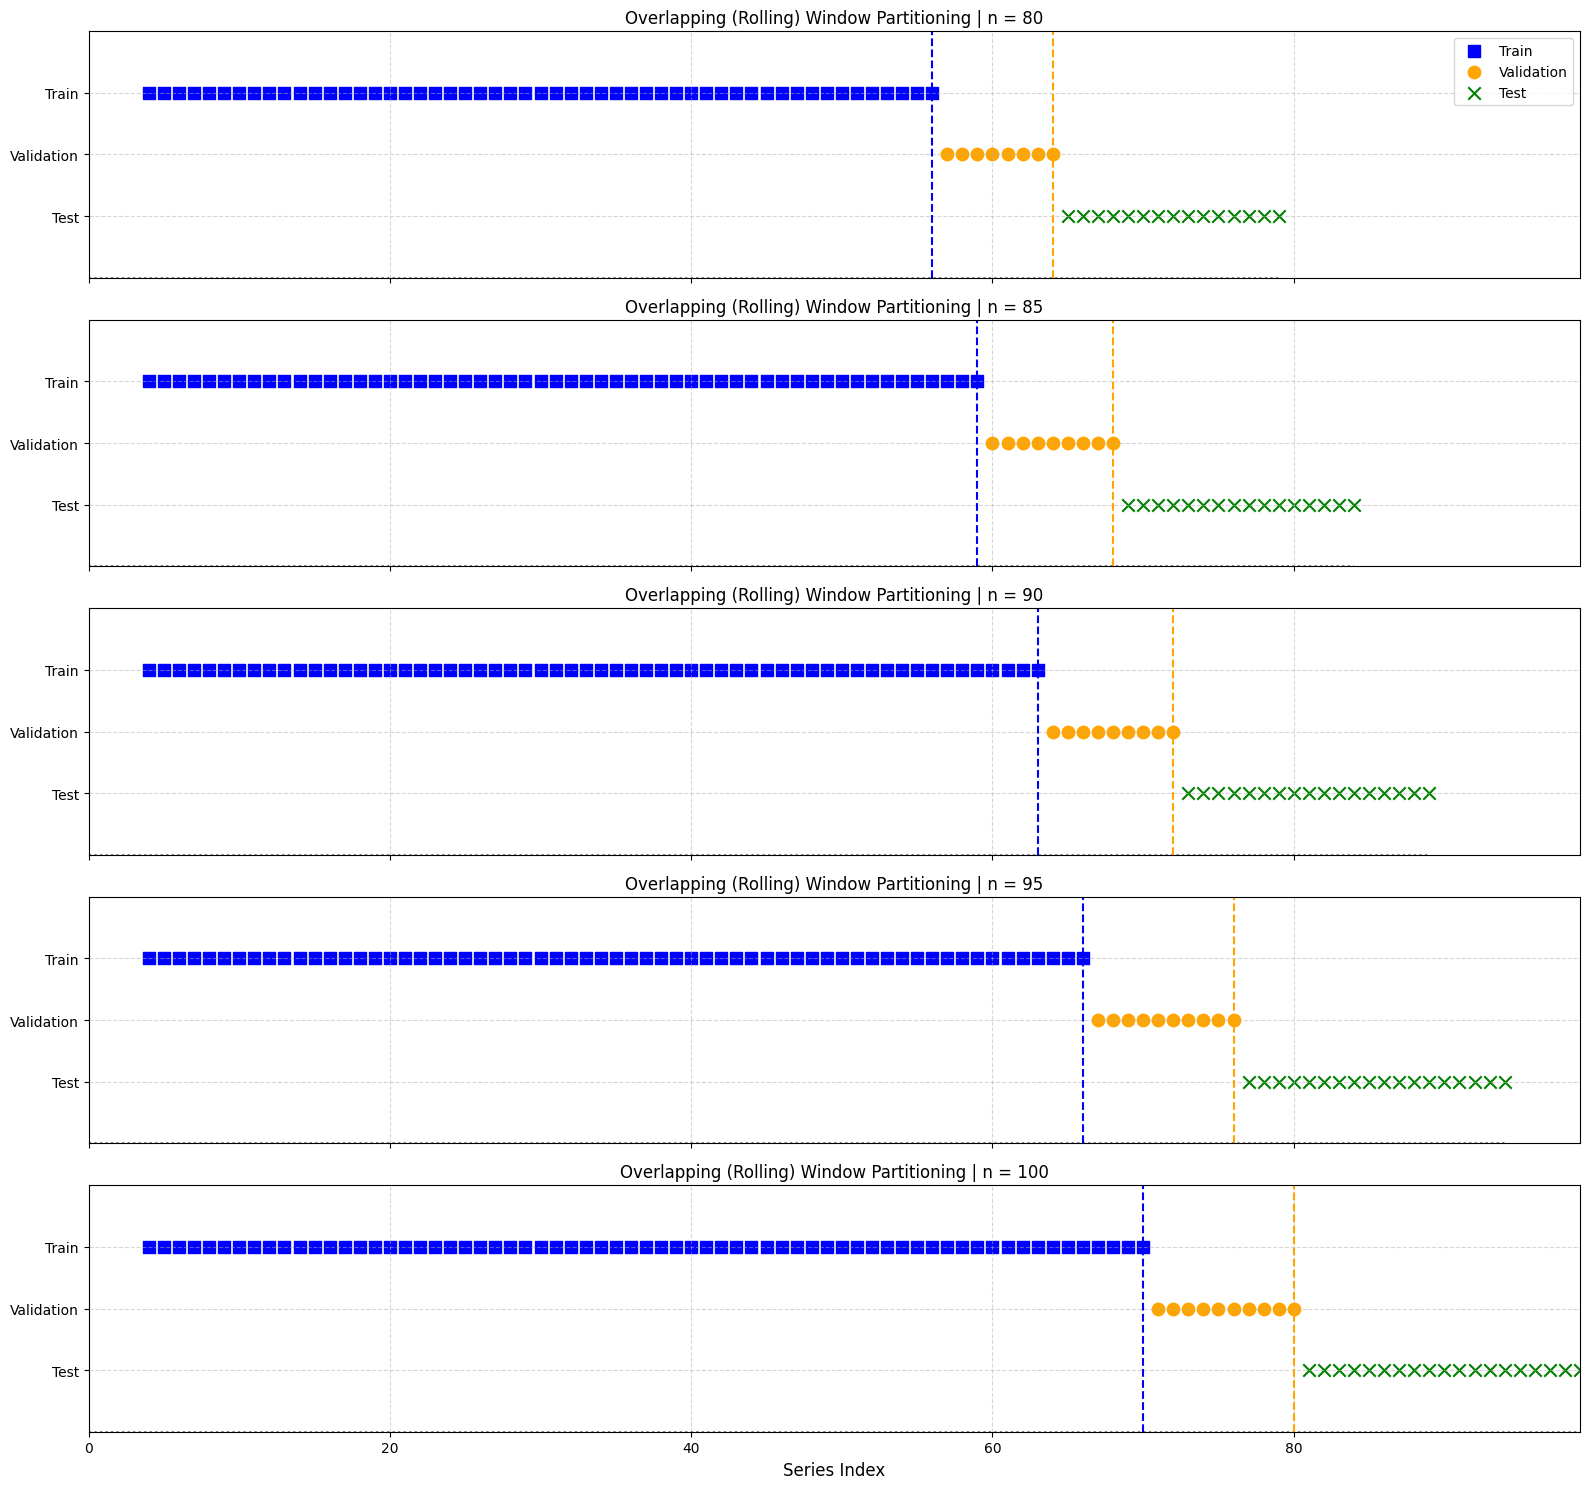


[INFO] TimeSeriesSplit (Fixed-Window CV)
[INFO] TimeSeriesSplit (Fixed-Window CV): Generating partition for series of length 80
[INFO] TimeSeriesSplit (Fixed-Window CV): Generating partition for series of length 85
[INFO] TimeSeriesSplit (Fixed-Window CV): Generating partition for series of length 90
[INFO] TimeSeriesSplit (Fixed-Window CV): Generating partition for series of length 95
[INFO] TimeSeriesSplit (Fixed-Window CV): Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


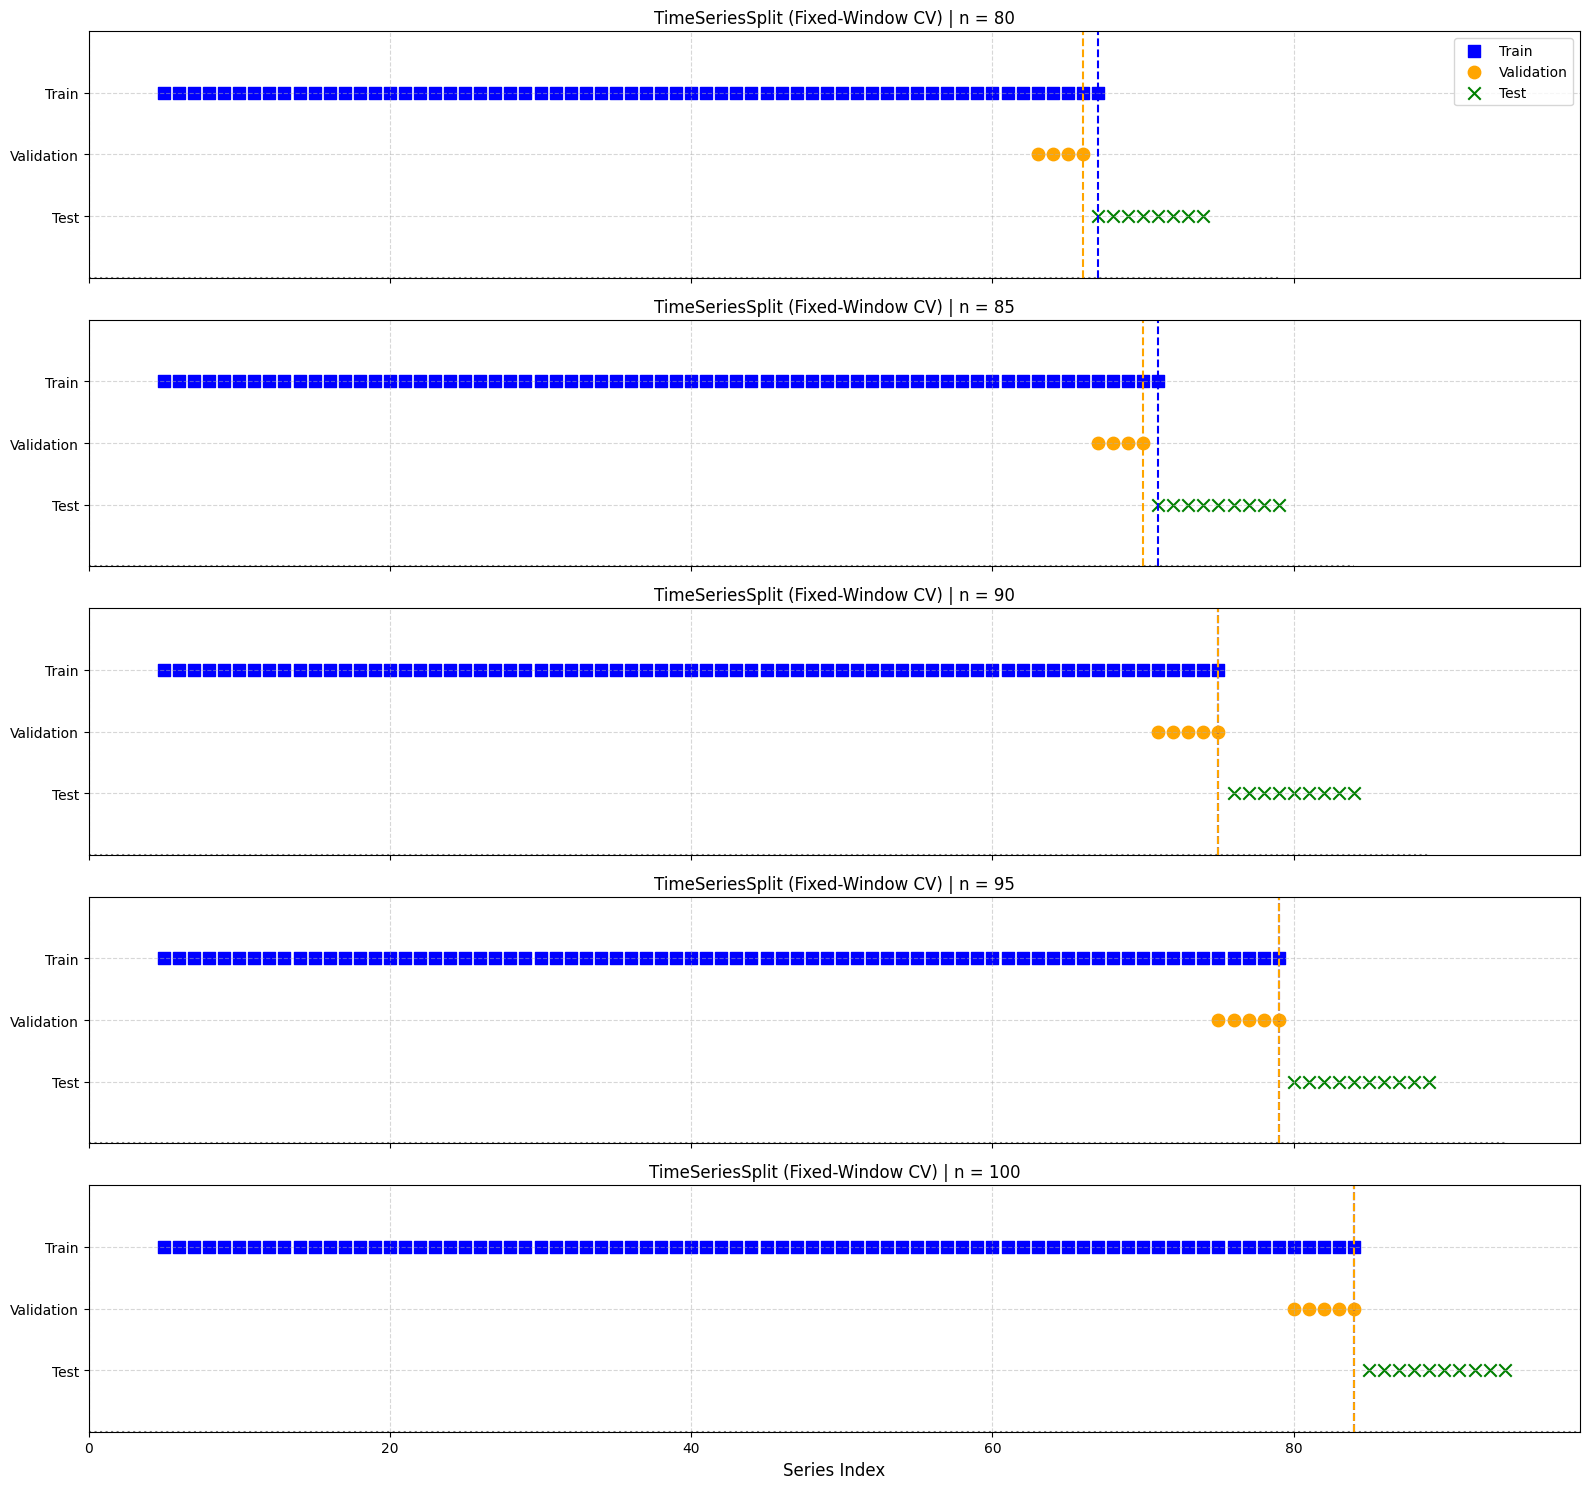


[INFO] Generator-Based Temporal Partitioning
[INFO] Generator-Based Temporal Partitioning: Generating partition for series of length 80
[INFO] Generator-Based Temporal Partitioning: Generating partition for series of length 85
[INFO] Generator-Based Temporal Partitioning: Generating partition for series of length 90
[INFO] Generator-Based Temporal Partitioning: Generating partition for series of length 95
[INFO] Generator-Based Temporal Partitioning: Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


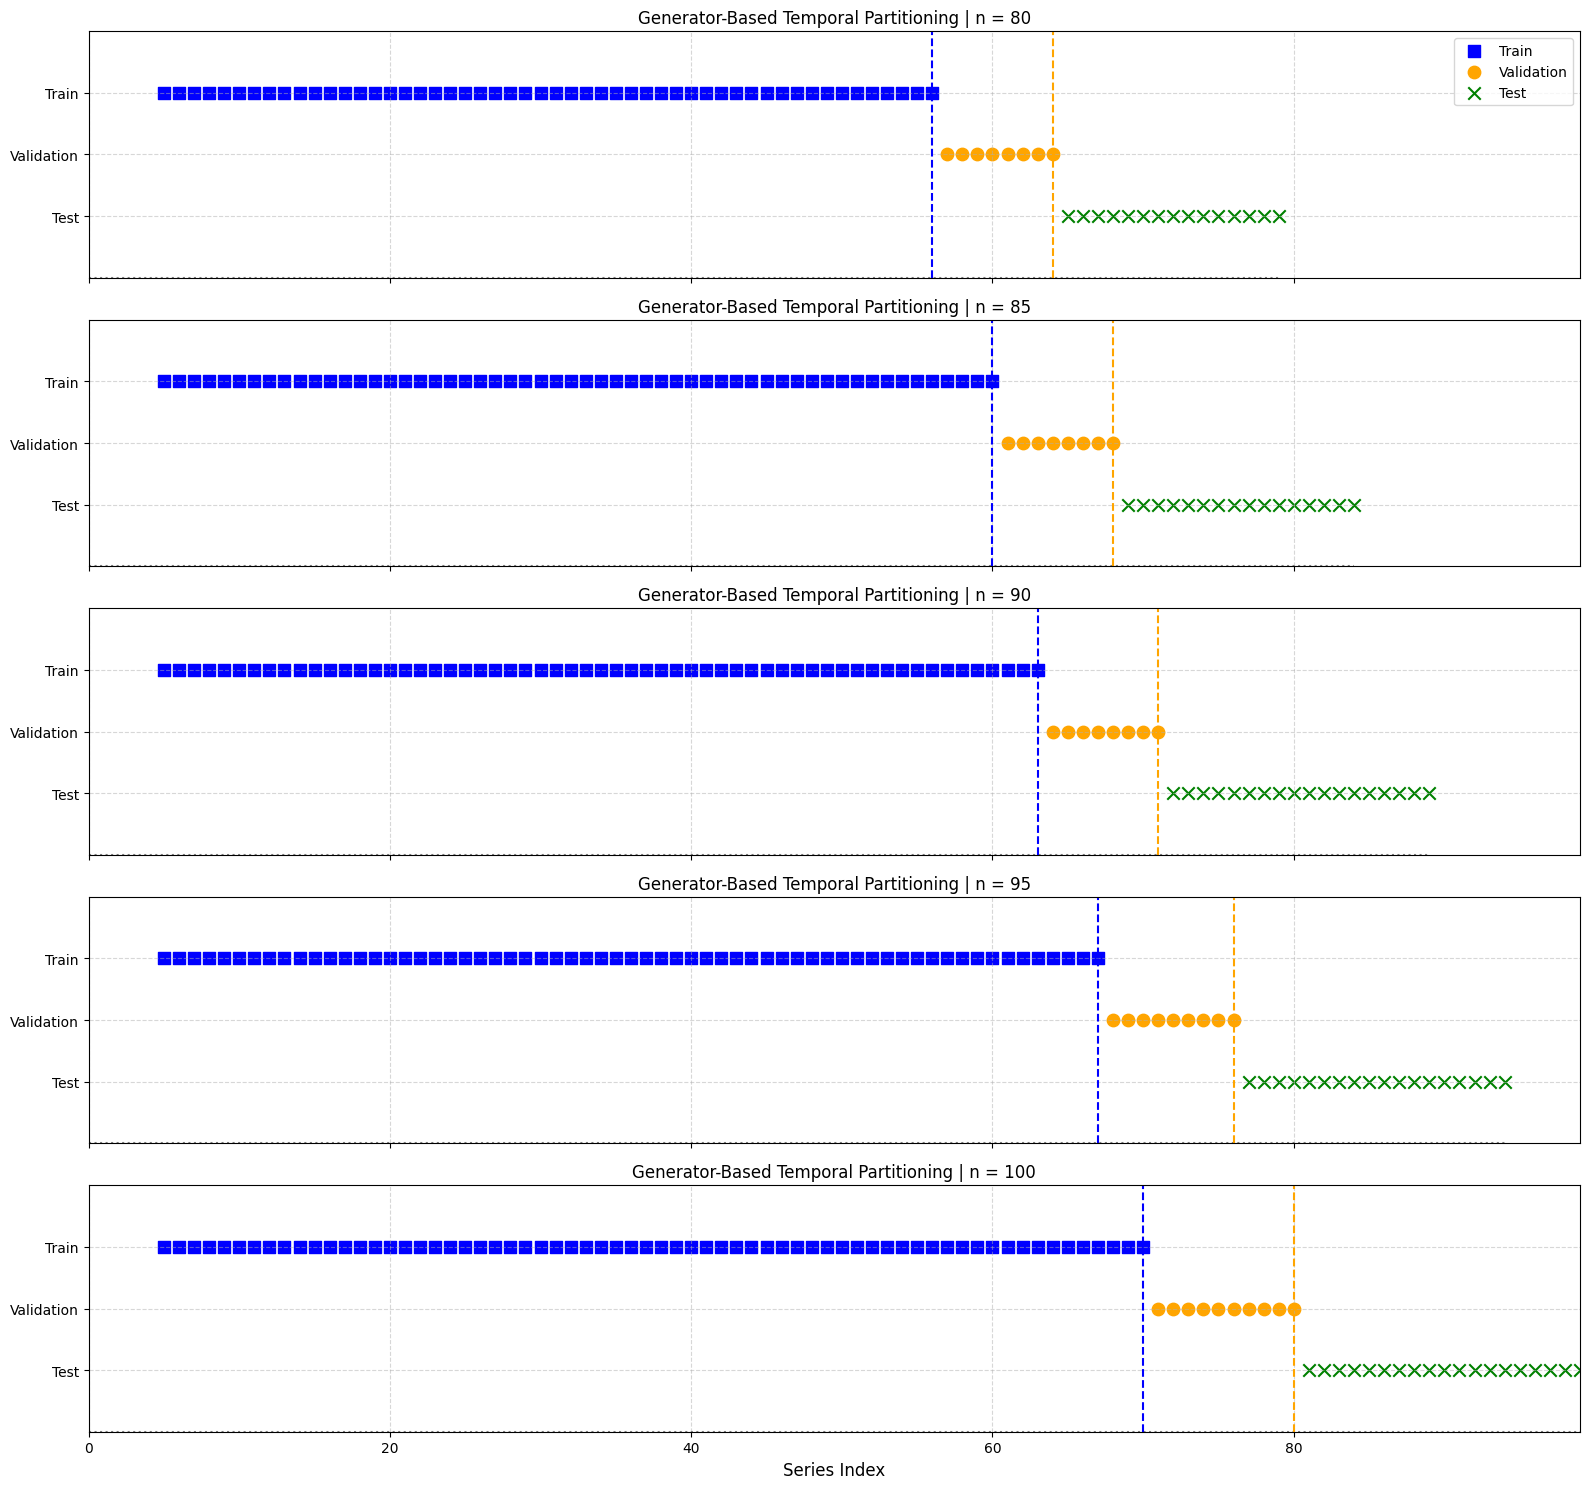


[INFO] Purged K-Fold Cross-Validation
[INFO] Purged K-Fold Cross-Validation: Generating partition for series of length 80
[INFO] Purged K-Fold Cross-Validation: Generating partition for series of length 85
[INFO] Purged K-Fold Cross-Validation: Generating partition for series of length 90
[INFO] Purged K-Fold Cross-Validation: Generating partition for series of length 95
[INFO] Purged K-Fold Cross-Validation: Generating partition for series of length 100
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


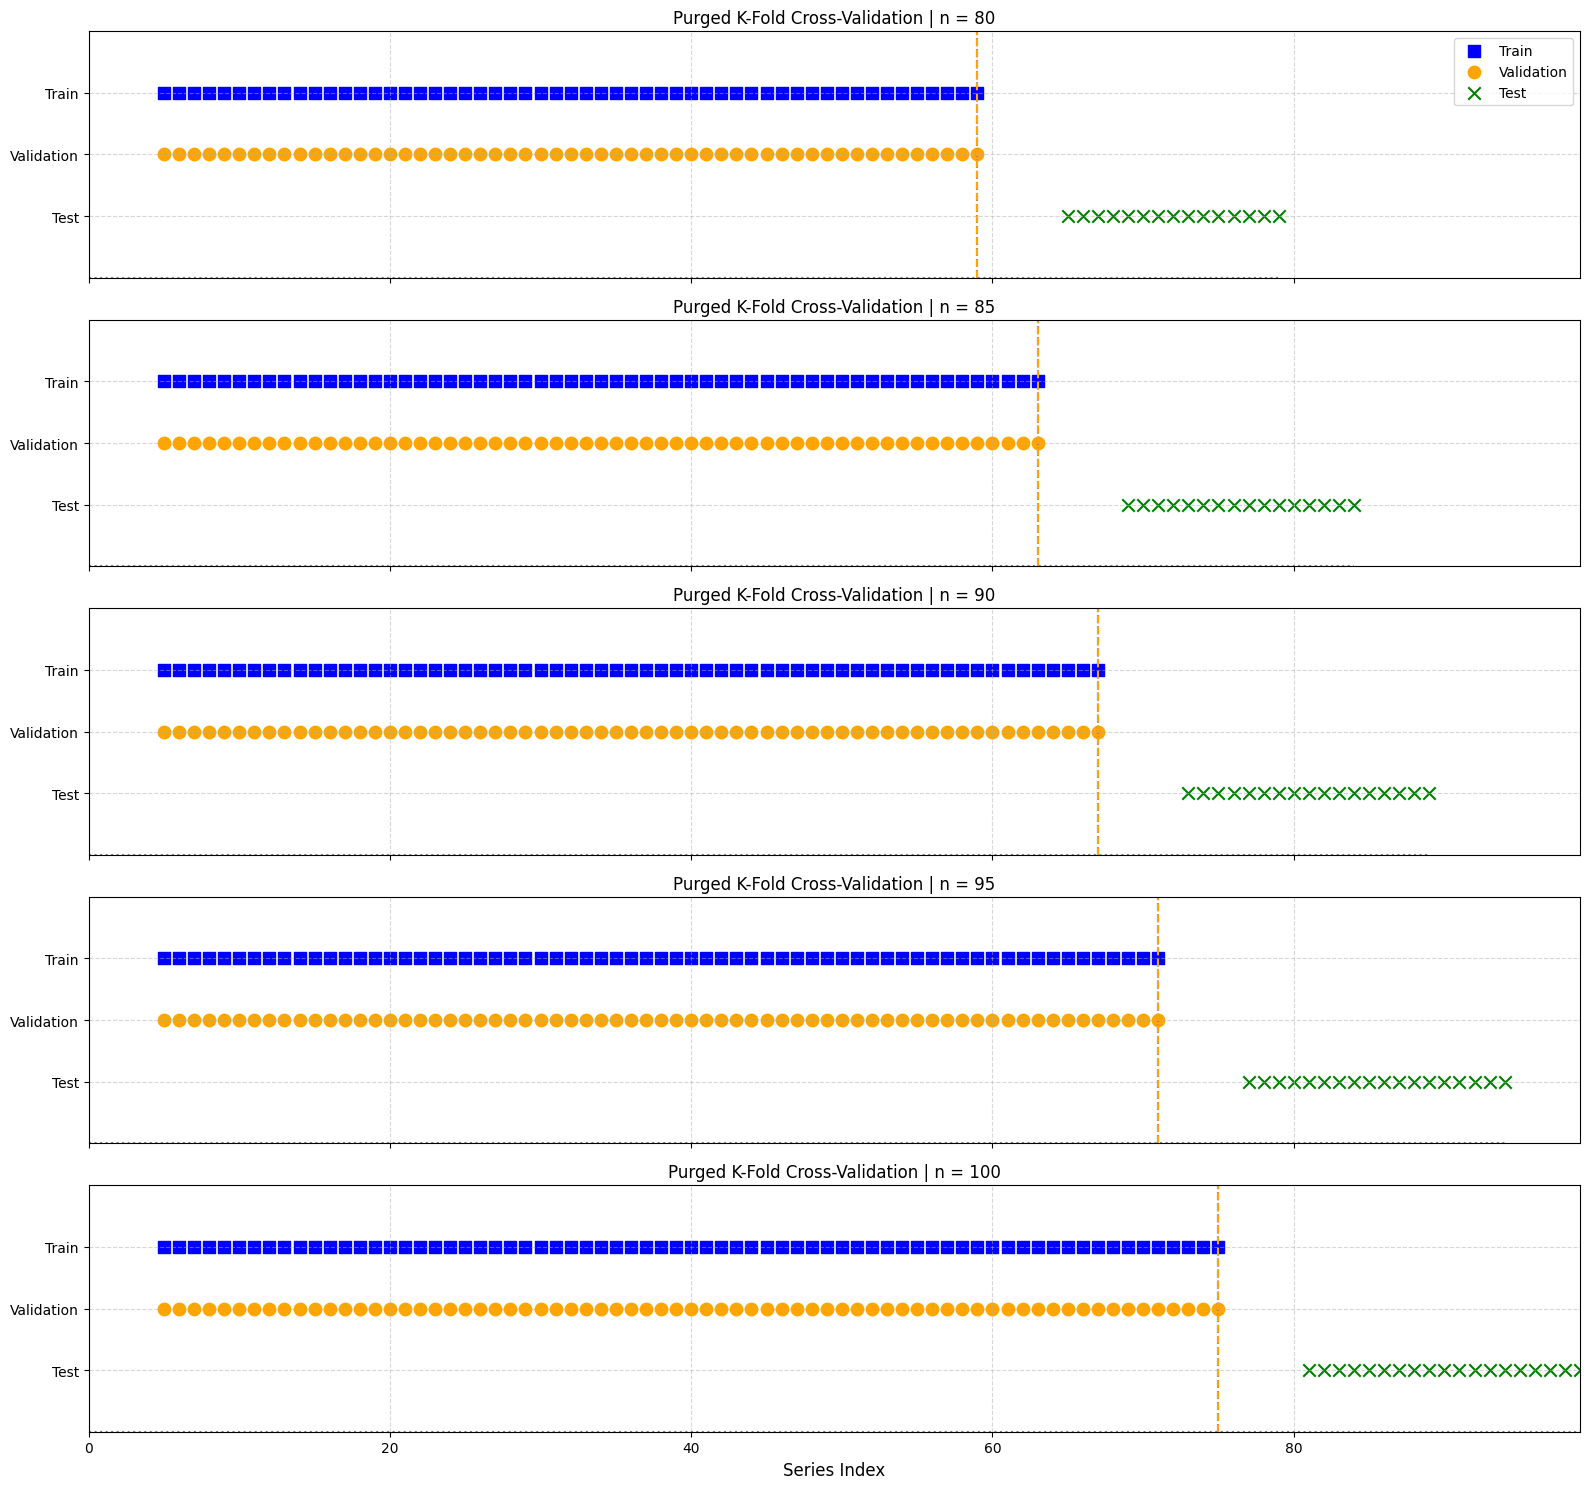


[INFO] Change-Point Based Partitioning
[INFO] Change-Point Based Partitioning: Generating partition for series of length 80
[INFO] Change-Point Based Partitioning generated. cp1: 50, cp2: 65
[INFO] Change-Point Based Partitioning: Generating partition for series of length 85
[INFO] Change-Point Based Partitioning generated. cp1: 55, cp2: 69
[INFO] Change-Point Based Partitioning: Generating partition for series of length 90
[INFO] Change-Point Based Partitioning generated. cp1: 60, cp2: 72
[INFO] Change-Point Based Partitioning: Generating partition for series of length 95
[INFO] Change-Point Based Partitioning generated. cp1: 60, cp2: 77
[INFO] Change-Point Based Partitioning: Generating partition for series of length 100
[INFO] Change-Point Based Partitioning generated. cp1: 65, cp2: 81
[INFO] Evolving partitions plot saved as 'evolving_partitions.png'


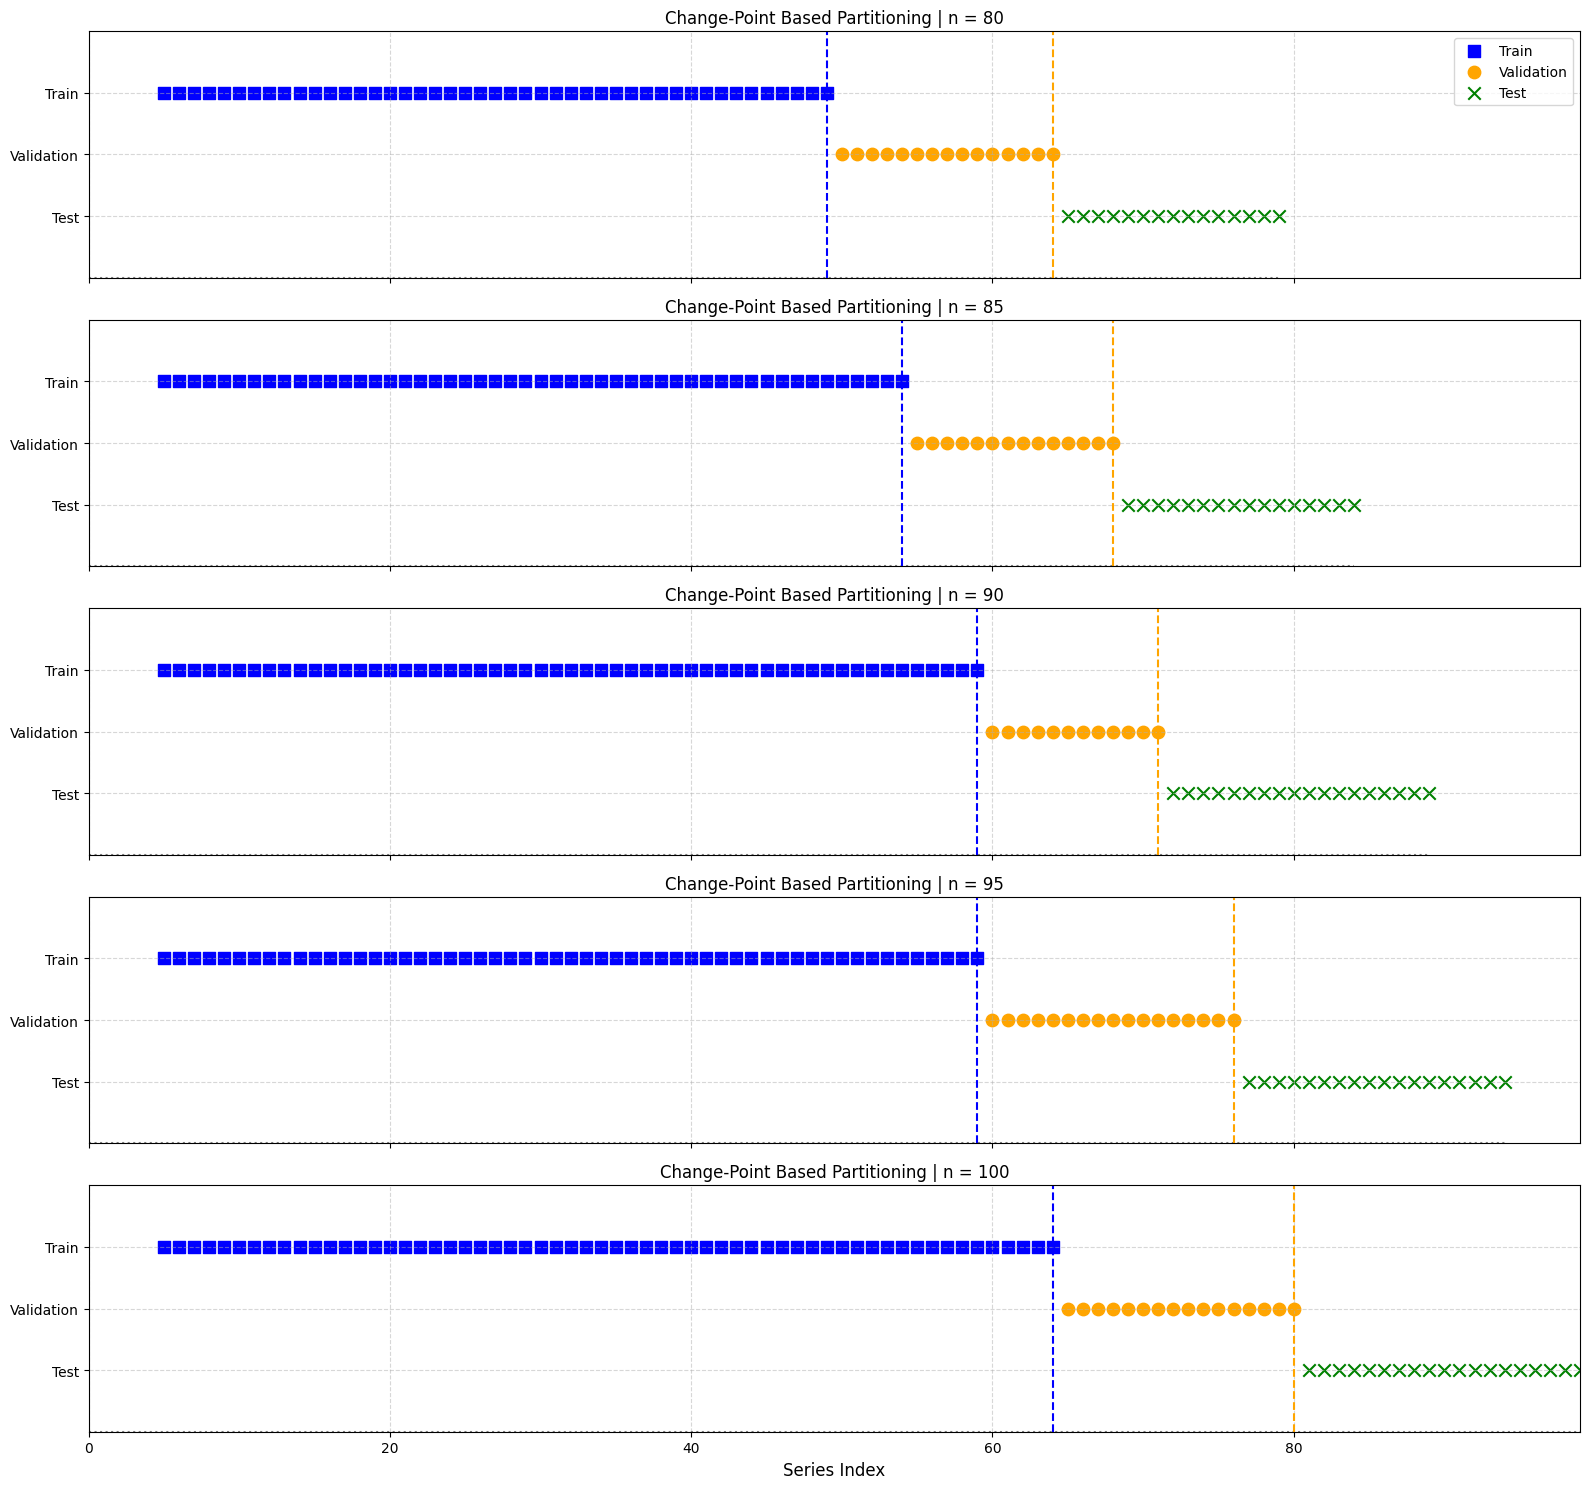

[INFO] Starting evaluation of all combinations of assets, models, and partitioning methods
[INFO] Combination 1/225: Asset 'ATT', Model 'GRU', method 'no_aleatoria'
[INFO] Evaluating model 'GRU' on asset 'ATT' using Chronological Hold-Out
[INFO] Chronological Hold-Out: Generating partition for series of length 2767
[INFO] Training model <lambda> for 100 epochs
[INFO] Building optimized GRU model for ATT with parameters: {'units': [128, 64], 'dropout': 0.1, 'learning_rate': 0.001, 'epochs': 100}


[codecarbon INFO @ 23:39:44] [setup] RAM Tracking...
[codecarbon INFO @ 23:39:44] [setup] CPU Tracking...
[codecarbon WARNING @ 23:39:44] No CPU tracking mode found. Falling back on CPU constant mode. 
 Linux OS detected: Please ensure RAPL files exist at \sys\class\powercap\intel-rapl to measure CPU

[codecarbon WARNING @ 23:39:46] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon INFO @ 23:39:46] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 23:39:46] [setup] GPU Tracking...
[codecarbon INFO @ 23:39:46] No GPU found.
[codecarbon INFO @ 23:39:46] >>> Tracker's metadata:
[codecarbon INFO @ 23:39:46]   Platform system: Linux-6.1.85+-x86_64-with-glibc2.35
[codecarbon INFO @ 23:39:46]   Python version: 3.11.11
[codecarbon INFO @ 23:39:46]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 23:39:46]   Available RAM : 12.675 GB
[codecarbon INFO @ 23:39:46]   CPU count: 2
[codecarbon INFO @ 23:39

[INFO] Training completed in 145.33 seconds
[INFO] Estimated emissions: 0.0005 kgCO2eq


[codecarbon INFO @ 23:42:13] [setup] RAM Tracking...
[codecarbon INFO @ 23:42:13] [setup] CPU Tracking...
[codecarbon WARNING @ 23:42:13] No CPU tracking mode found. Falling back on CPU constant mode. 
 Linux OS detected: Please ensure RAPL files exist at \sys\class\powercap\intel-rapl to measure CPU



[INFO] Evaluation completed for model 'GRU', asset 'ATT' using Chronological Hold-Out
[INFO] Combination 1/225 completed. Remaining: 224.

[INFO] Combination 2/225: Asset 'ATT', Model 'GRU', method 'secuencial_con_mezcla'
[INFO] Evaluating model 'GRU' on asset 'ATT' using Sequential (Contiguous) Split
[INFO] Sequential (Contiguous) Split: Generating partition for series of length 2767
[INFO] Training model <lambda> for 100 epochs
[INFO] Building optimized GRU model for ATT with parameters: {'units': [128, 64], 'dropout': 0.1, 'learning_rate': 0.001, 'epochs': 100}


...

[codecarbon WARNING @ 23:44:44] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon INFO @ 23:44:44] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 23:44:44] [setup] GPU Tracking...
[codecarbon INFO @ 23:44:44] No GPU found.
[codecarbon INFO @ 23:44:44] >>> Tracker's metadata:
[codecarbon INFO @ 23:44:44]   Platform system: Linux-6.1.85+-x86_64-with-glibc2.35
[codecarbon INFO @ 23:44:44]   Python version: 3.11.11
[codecarbon INFO @ 23:44:44]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 23:44:44]   Available RAM : 12.675 GB
[codecarbon INFO @ 23:44:44]   CPU count: 2
[codecarbon INFO @ 23:44:44]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 23:44:44]   GPU count: None
[codecarbon INFO @ 23:44:44]   GPU model: None
[codecarbon INFO @ 23:44:45] Saving emissions data to file /content/emissions.csv
[codecarbon INFO @ 23:45:00] Energy consumed for RAM : 0.000020 kWh. RAM Power

[INFO] Training completed in 137.28 seconds
[INFO] Estimated emissions: 0.0005 kgCO2eq


[codecarbon INFO @ 23:47:04] [setup] RAM Tracking...
[codecarbon INFO @ 23:47:04] [setup] CPU Tracking...
[codecarbon WARNING @ 23:47:04] No CPU tracking mode found. Falling back on CPU constant mode. 
 Linux OS detected: Please ensure RAPL files exist at \sys\class\powercap\intel-rapl to measure CPU



[INFO] Evaluation completed for model 'GRU', asset 'ATT' using Sequential Split (Without Shuffle)
[INFO] Combination 3/225 completed. Remaining: 222.

[INFO] Combination 4/225: Asset 'ATT', Model 'GRU', method 'ventana_movil2'
[INFO] Evaluating model 'GRU' on asset 'ATT' using Expanding Window Validation
[INFO] Expanding Window Validation: Generating partition for series of length 2767
[INFO] Training model <lambda> for 100 epochs
[INFO] Building optimized GRU model for ATT with parameters: {'units': [128, 64], 'dropout': 0.1, 'learning_rate': 0.001, 'epochs': 100}


[codecarbon WARNING @ 23:47:06] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon INFO @ 23:47:06] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 23:47:06] [setup] GPU Tracking...
[codecarbon INFO @ 23:47:06] No GPU found.
[codecarbon INFO @ 23:47:06] >>> Tracker's metadata:
[codecarbon INFO @ 23:47:06]   Platform system: Linux-6.1.85+-x86_64-with-glibc2.35
[codecarbon INFO @ 23:47:06]   Python version: 3.11.11
[codecarbon INFO @ 23:47:06]   CodeCarbon version: 2.8.3
[codecarbon INFO @ 23:47:06]   Available RAM : 12.675 GB
[codecarbon INFO @ 23:47:06]   CPU count: 2
[codecarbon INFO @ 23:47:06]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 23:47:06]   GPU count: None
[codecarbon INFO @ 23:47:06]   GPU model: None
[codecarbon INFO @ 23:47:06] Saving emissions data to file /content/emissions.csv
[codecarbon INFO @ 23:47:21] Energy consumed for RAM : 0.000020 kWh. RAM Power

In [ ]:
# %% Configuración de la semilla
seed = 123
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# %% Parámetros globales
WINDOW_SIZE = 5
TRAIN_PERCENT = 0.70
TEST_PERCENT = 0.20  # 10% validation
LEARNING_RATE = 0.001

EPOCHS_DICT = {
    "Linear": 75,
    "Multilayer Perceptron": 75,
    "LSTM": 100,
    "GRU": 100,
    "TRANSFORMER": 150,
    "BiLSTM": 100
}

STEP = 5
MAX_PARTITIONS = 20

# Nombres oficiales de métodos
METODOS_MAP = {
    "no_aleatoria": "Chronological Hold-Out",
    "secuencial_con_mezcla": "Sequential (Contiguous) Split",
    "pre-paper_no_shuffle": "Sequential Split (Without Shuffle)",
    "ventana_movil2": "Expanding Window Validation",
    "con_solape": "Overlapping (Rolling) Window Partitioning",
    "time_series_split": "TimeSeriesSplit (Fixed-Window CV)",
    "timeseries_generator": "Generator-Based Temporal Partitioning",
    "purged_kfold": "Purged K-Fold Cross-Validation",
    "change_point_partitioning": "Change-Point Based Partitioning"
}
METODOS_PARTICION = list(METODOS_MAP.keys())

# Diccionario con todos los activos a entrenar
activos = {
    "Bitcoin": {"ticker": "BTC-USD", "start": "2009-01-01", "end": "2024-12-31"},
    "Ethereum": {"ticker": "ETH-USD", "start": "2015-01-01", "end": "2024-12-31"},
    "Litecoin": {"ticker": "LTC-USD", "start": "2011-01-01", "end": "2024-12-31"},
    "Bitcoin Cash": {"ticker": "BCH-USD", "start": "2017-01-01", "end": "2024-12-31"},
    "Cardano": {"ticker": "ADA-USD", "start": "2017-01-01", "end": "2024-12-31"},
    "Polkadot": {"ticker": "DOT-USD", "start": "2020-01-01", "end": "2024-12-31"},
    "Solana": {"ticker": "SOL-USD", "start": "2020-01-01", "end": "2024-12-31"},
    "Binance Coin": {"ticker": "BNB-USD", "start": "2017-01-01", "end": "2024-12-31"},
    "TRON": {"ticker": "TRX-USD", "start": "2017-01-01", "end": "2024-12-31"},
    "Monero": {"ticker": "XMR-USD", "start": "2014-01-01", "end": "2024-12-31"},
    "Ripple": {"ticker": "XRP-USD", "start": "2012-01-01", "end": "2024-12-31"},
    "Stellar": {"ticker": "XLM-USD", "start": "2014-01-01", "end": "2024-12-31"}
}

# Descarga de datos y escalado
series_dict = {}
dates_dict = {}
scalers = {}
for nombre, info in activos.items():
    print(f"[INFO] Downloading data for {nombre} (ticker: {info['ticker']})...")
    data = yf.download(info["ticker"], start=info["start"], end=info["end"], interval="1d")['Close'].dropna()
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data.values.reshape(-1, 1)).flatten()
    series_dict[nombre] = scaled_data
    dates_dict[nombre] = data.index
    scalers[nombre] = scaler
    print(f"[INFO] Download completed for {nombre}. Records: {len(data)}")

# %% Selección de series y modelos a analizar
available_series = list(series_dict.keys())
print("Available series options: all, " + ", ".join(available_series))
selected_series = input("Enter the series to analyze (options: all, " + ", ".join(available_series) + "): ").strip()
if selected_series.lower() == "all":
    series_to_analyze = available_series
else:
    series_to_analyze = [s.strip() for s in selected_series.split(",") if s.strip() in series_dict]

available_models = ["Multilayer Perceptron", "LSTM", "GRU", "TRANSFORMER", "BiLSTM"]
print("Available algorithms: all, " + ", ".join(available_models))
selected_models = input("Enter the algorithms to analyze (options: all, " + ", ".join(available_models) + "): ").strip()
if selected_models.lower() == "all":
    models_to_analyze = available_models
else:
    models_to_analyze = [m.strip() for m in selected_models.split(",") if m.strip() in available_models]

print(f"[INFO] Selected series: {series_to_analyze}")
print(f"[INFO] Selected algorithms: {models_to_analyze}")

# %% Bloque evolutivo: Visualización de particiones para cada método
print("\n[INFO] Evolutionary visualization of partitions (stepped levels) for each method:")
n_min = 80
n_max = 100
steps = 5

METODOS_FUNC = {
    "Chronological Hold-Out": chronological_holdout,
    "Sequential (Contiguous) Split": sequential_contiguous_split,
    "Sequential Split (Without Shuffle)": sequential_split_no_shuffle,
    "Expanding Window Validation": expanding_window_validation,
    "Overlapping (Rolling) Window Partitioning": overlapping_window_partitioning,
    "TimeSeriesSplit (Fixed-Window CV)": timeseries_split_fixed_cv,
    "Generator-Based Temporal Partitioning": generator_based_temporal_partitioning,
    "Purged K-Fold Cross-Validation": purged_kfold_cv,
    "Change-Point Based Partitioning": changepoint_based_partitioning
}

for nombre, func in METODOS_FUNC.items():
    print(f"\n[INFO] {nombre}")
    try:
        n_vals, particiones = particiones_evolutivas(func, n_min, n_max, steps)
        fig, axes = plt.subplots(steps, 1, figsize=(16, 3*steps), sharex=True)
        if steps == 1:
            axes = [axes]
        for i, (n_actual, idx_train, idx_val, idx_test) in enumerate(particiones):
            axes[i].hlines(0, 0, n_actual-1, colors='gray', linestyles='dotted')
            axes[i].scatter(idx_train, np.full_like(idx_train, 3), color='blue', label='Train', s=80, marker='s')
            axes[i].scatter(idx_val, np.full_like(idx_val, 2), color='orange', label='Validation', s=80, marker='o')
            axes[i].scatter(idx_test, np.full_like(idx_test, 1), color='green', label='Test', s=80, marker='x')
            if len(idx_train) > 0:
                axes[i].axvline(x=idx_train[-1], color='blue', linestyle='--', linewidth=1.5)
            if len(idx_val) > 0:
                axes[i].axvline(x=idx_val[-1], color='orange', linestyle='--', linewidth=1.5)
            axes[i].set_title(f"{nombre} | n = {n_actual}", fontsize=12)
            axes[i].set_xlim(0, n_actual-1)
            axes[i].set_ylim(0, 4)
            axes[i].set_yticks([1, 2, 3])
            axes[i].set_yticklabels(["Test", "Validation", "Train"], fontsize=10)
            axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[0].legend(loc='upper right', fontsize=10)
        plt.xlabel("Series Index", fontsize=12)
        plt.tight_layout()
        plt.savefig("evolving_partitions.png")
        print("[INFO] Evolving partitions plot saved as 'evolving_partitions.png'")
        plt.show(fig)
    except Exception as e:
        print(f"[ERROR] {nombre} generated error: {e}")

# %% Bloque de evaluación global
print("[INFO] Starting evaluation of all combinations of assets, models, and partitioning methods")
total_comb = len(series_dict) * len(modelos) * len(METODOS_PARTICION)
current_comb = 0
global_results_by_asset = {}

for asset_name in series_to_analyze:
    global_results_by_asset[asset_name] = {}
    for model_name in models_to_analyze:
        global_results_by_asset[asset_name][model_name] = []
        for metodo in METODOS_PARTICION:
            current_comb += 1
            print(f"[INFO] Combination {current_comb}/{total_comb}: Asset '{asset_name}', Model '{model_name}', method '{metodo}'")
            res = evaluate_model_asset(model_name, modelos[model_name], asset_name, series_dict[asset_name], metodo, EPOCHS_DICT[model_name])
            if res is not None:
                global_results_by_asset[asset_name][model_name].append(res)
            print(f"[INFO] Combination {current_comb}/{total_comb} completed. Remaining: {total_comb - current_comb}.\n")
    print(f"[INFO] INDIVIDUAL RESULTS FOR ASSET '{asset_name}'")
    for model, res_list in global_results_by_asset[asset_name].items():
        if res_list:
            tabla_individual = []
            for r in res_list:
                emis_str = f"{r['emissions']:.7f}" if r["emissions"] is not None else "N/A"
                tabla_individual.append([
                    model,
                    METODOS_MAP[r["method"]],
                    f"{r['mse']:.4f}" if r["mse"] is not None else "N/A",
                    f"{r['rmse']:.4f}" if r["rmse"] is not None else "N/A",
                    f"{r['mae']:.4f}" if r["mae"] is not None else "N/A",
                    f"{r['mape']:.4f}" if r["mape"] is not None else "N/A",
                    f"{r['r2']:.4f}" if r["r2"] is not None else "N/A",
                    f"{r['time']:.4f}" if r["time"] is not None else "N/A",
                    emis_str,
                    r["n_train"],
                    r["n_val"],
                    r["n_test"],
                    r["train_range"],
                    r["valid_range"],
                    r["test_range"],
                    r["total_samples"],
                    r["n_original"]
                ])
            table_output = tabulate(
                tabla_individual,
                headers=[
                    "Model", "Method", "MSE", "RMSE", "MAE", "MAPE", "R²", "Time (s)",
                    "Emissions (kgCO2eq)", "Train", "Validation", "Test",
                    "Train Range", "Validation Range", "Test Range",
                    "Total", "Original N"
                ],
                tablefmt="grid"
            )
            print(table_output)
            with open(f"table_{asset_name}_{model}.txt", "w") as f:
                f.write(table_output)
    print("\n======================================================\n")

# Construir global_results_by_model a partir de global_results_by_asset
global_results_by_model = {}
for asset, models_results in global_results_by_asset.items():
    for model, res_list in models_results.items():
        if model not in global_results_by_model:
            global_results_by_model[model] = {}
        global_results_by_model[model][asset] = res_list

# %% Generación de tabla global (adaptada)
global_non_iter = {}
for asset, models_results in global_results_by_asset.items():
    for model, res_list in models_results.items():
        for r in res_list:
            met = r["method"]
            if met not in global_non_iter:
                global_non_iter[met] = {
                    "asset": set(),
                    "model": set(),
                    "mse": [], "rmse": [], "mae": [], "mape": [], "r2": [], "time": [],
                    "emissions": [],
                    "n_train": [], "n_val": [], "n_test": [],
                    "train_range": [], "valid_range": [], "test_range": [],
                    "total_samples": [], "n_original": []
                }
            global_non_iter[met]["asset"].add(asset)
            global_non_iter[met]["model"].add(model)
            global_non_iter[met]["mse"].append(r["mse"])
            global_non_iter[met]["rmse"].append(r["rmse"])
            global_non_iter[met]["mae"].append(r["mae"])
            global_non_iter[met]["mape"].append(r["mape"])
            global_non_iter[met]["r2"].append(r["r2"])
            global_non_iter[met]["time"].append(r["time"])
            global_non_iter[met]["emissions"].append(r["emissions"])
            global_non_iter[met]["n_train"].append(r["n_train"])
            global_non_iter[met]["n_val"].append(r["n_val"])
            global_non_iter[met]["n_test"].append(r["n_test"])
            global_non_iter[met]["train_range"].append(r["train_range"])
            global_non_iter[met]["valid_range"].append(r["valid_range"])
            global_non_iter[met]["test_range"].append(r["test_range"])
            global_non_iter[met]["total_samples"].append(r["total_samples"])
            global_non_iter[met]["n_original"].append(r["n_original"])

if global_non_iter:
    tabla_global = []
    for met, metrics in global_non_iter.items():
        activos_str = ", ".join(sorted(metrics["asset"]))
        modelos_str = ", ".join(sorted(metrics["model"]))
        emis_mean = np.mean(metrics['emissions'])
        emis_str_mean = f"{emis_mean:.7f}" if not np.isnan(emis_mean) else "N/A"
        tabla_global.append([
            activos_str,
            modelos_str,
            METODOS_MAP[met],
            f"{np.mean(metrics['mse']):.4f}",
            f"{np.mean(metrics['rmse']):.4f}",
            f"{np.mean(metrics['mae']):.4f}",
            f"{np.mean(metrics['mape']):.4f}",
            f"{np.mean(metrics['r2']):.4f}",
            f"{np.mean(metrics['time']):.4f}",
            emis_str_mean,
            int(np.mean(metrics['n_train'])),
            int(np.mean(metrics['n_val'])),
            int(np.mean(metrics['n_test'])),
            metrics['train_range'][0],
            metrics['valid_range'][0],
            metrics['test_range'][0],
            int(np.mean(metrics['total_samples'])),
            int(np.mean(metrics['n_original']))
        ])
    global_table = tabulate(
        tabla_global,
        headers=[
            "Assets", "Models", "Method", "MSE", "RMSE", "MAE", "MAPE", "R²", "Time (s)",
            "Emissions (kgCO2eq)", "Train", "Validation", "Test",
            "Train Range", "Validation Range", "Test Range",
            "Total", "Original N"
        ],
        tablefmt="grid"
    )
    print(global_table)
    with open(f"global_table.txt", "w") as f:
        f.write(global_table)
else:
    print("[INFO] No global results obtained.")
print("\n======================================================\n")

# %% Visualizaciones globales
for model_name, asset_results in global_results_by_model.items():
    all_results = []
    for asset_name, res_list in asset_results.items():
        for r in res_list:
            all_results.append((asset_name, model_name, r))
    if all_results:
        n_plots = len(all_results)
        nrows = math.ceil(n_plots / 2)
        fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(16, 6 * nrows))
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
        for i, (asset_name, model_name, result_item) in enumerate(all_results):
            preds, reales = result_item["preds_list"][0]
            test_dates = result_item["test_dates"]
            ax = axes[i]
            ax.plot(test_dates, reales, label='Real', color='blue')
            ax.plot(test_dates, preds, label='Pred', color='orange')
            ax.set_title(f"{result_item['model']}\nAsset: {asset_name}, Method: {METODOS_MAP[result_item['method']]}", fontsize=12)
            ax.tick_params(axis='x', rotation=45, labelsize=10)
            ax.legend(fontsize=10)
        plt.tight_layout()
        lineplot_filename = f"lineplots_global.png"
        plt.savefig(lineplot_filename)
        print(f"[INFO] Global line plot saved as {lineplot_filename}")
        plt.show(fig)

        metric_keys = ["mse", "rmse", "mae", "mape", "r2", "time", "emissions"]
        metric_labels = ["MSE", "RMSE", "MAE", "MAPE", "R²", "Time (s)", "Emissions (kgCO2eq)"]
        metrics_boxplot = {m: {} for m in metric_keys}

        for asset_name, res_list in asset_results.items():
            for r in res_list:
                metodo = r["method"]
                for mk in metric_keys:
                    if metodo not in metrics_boxplot[mk]:
                        metrics_boxplot[mk][metodo] = []
                    val = r[mk]
                    if val is not None:
                        metrics_boxplot[mk][metodo].append(val)

        for mk, mk_label in zip(metric_keys, metric_labels):
            data_box = [metrics_boxplot[mk][m] for m in METODOS_PARTICION if m in metrics_boxplot[mk]]
            labels_box = [METODOS_MAP[m] for m in METODOS_PARTICION if m in metrics_boxplot[mk]]
            if not data_box:
                continue
            plt.figure(figsize=(16, 8))
            bp = plt.boxplot(data_box, labels=labels_box, patch_artist=True)
            for box in bp['boxes']:
                box.set(facecolor='#D0E1F9')
            plt.title(f"Global Boxplot of {mk_label}", fontsize=18)
            plt.xlabel("Partitioning Method", fontsize=16)
            plt.ylabel(mk_label, fontsize=16)
            plt.xticks(rotation=45, ha='right', fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.5)
            if mk == "emissions":
                plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.7f'))
            plt.tight_layout()
            boxplot_filename = f"boxplot_{mk_label}_{model_name}.png"
            plt.savefig(boxplot_filename)
            print(f"[INFO] Boxplot of {mk_label} saved as {boxplot_filename}")
            plt.show()

        df_rows = []
        for mk, mk_label in zip(metric_keys, metric_labels):
            for metodo in METODOS_PARTICION:
                if metodo in metrics_boxplot[mk]:
                    for valor in metrics_boxplot[mk][metodo]:
                        df_rows.append({"Asset": model_name, "Method": METODOS_MAP[metodo], "Metric": mk_label, "Value": valor})

        if df_rows:
            df_box = pd.DataFrame(df_rows)
            for metric_name in df_box["Metric"].unique():
                df_metric = df_box[df_box["Metric"] == metric_name]
                plt.figure(figsize=(16, 8))
                sns.violinplot(data=df_metric, x="Method", y="Value", color="lightblue", inner=None)
                sns.boxplot(data=df_metric, x="Method", y="Value", width=0.2,
                            boxprops={"zorder": 2, "facecolor": "white"})
                sns.stripplot(data=df_metric, x="Method", y="Value", color="black", size=4, alpha=0.6)
                plt.title(f"Violin + Box + Points | {metric_name} - {model_name}", fontsize=16)
                plt.xticks(rotation=45, ha='right', fontsize=12)
                plt.ylabel(metric_name, fontsize=14)
                plt.xlabel("Partitioning Method", fontsize=14)
                plt.grid(True, linestyle='--', alpha=0.5)
                if metric_name == "Emissions (kgCO2eq)":
                    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.7f'))
                plt.tight_layout()
                combo_filename = f"violin_box_strip_{metric_name}_{model_name}.png"
                plt.savefig(combo_filename)
                print(f"[INFO] Combined plot (violin+box+strip) for {metric_name} saved as {combo_filename}")
                plt.show()
        output_filename = f"results_{model_name}.pkl"
        with open(output_filename, "wb") as f:
            pickle.dump({model_name: asset_results}, f)
        print(f"[INFO] Results for model '{model_name}' saved in '{output_filename}'")

print("[INFO] Global evaluation completed\n")

# %% Guardar resultados globales en un CSV
all_results_flat = []
for asset, models_results in global_results_by_asset.items():
    for model, res_list in models_results.items():
        for r in res_list:
            if "preds_list" in r:
                r["preds_list"] = str(r["preds_list"])
            all_results_flat.append(r)

df_global = pd.DataFrame(all_results_flat)
column_order = [
    "model", "asset", "method", "mse", "rmse", "mae", "mape", "r2", "time", "emissions",
    "n_train", "n_val", "n_test", "train_range", "valid_range", "test_range",
    "total_samples", "n_original", "idx_test", "test_dates", "preds_list"
]
column_order = [col for col in column_order if col in df_global.columns]
df_global = df_global[column_order]
df_global.to_csv("global_results.csv", index=False)
print("[INFO] Global CSV saved as 'global_results.csv'")
